In [ ]:

from langchain_community.llms import Ollama
from langchain_community.embeddings import HuggingFaceEmbeddings

from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
import ipdb 

## Build the vector store

In [ ]:
from langchain.document_loaders import DirectoryLoader, PyPDFLoader
from langchain.text_splitter import CharacterTextSplitter, RecursiveCharacterTextSplitter
from langchain.vectorstores import Chroma 
from pathlib import Path
import glob
import os
LOCAL_VECTOR_STORE_DIR = Path('../vectorstore_test')
#TMP_DIR = Path(__file__).resolve().parent.joinpath('data', 'tmp')
#os.makedirs(TMP_DIR, exist_ok=True)

def load_documents(dirpath):
    document_list = []
    doc_files = glob.glob(f'{dirpath}/*.pdf')
    for doc in doc_files:
        document_list.extend(PyPDFLoader(doc).load())
    return document_list


def split_documents(documents):
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=700, chunk_overlap=20)
    texts = text_splitter.split_documents(documents)
    return texts

def create_vector_db_and_retriever(texts):
    vectordb = Chroma.from_documents(texts, embedding=HuggingFaceEmbeddings(),
                                     persist_directory=LOCAL_VECTOR_STORE_DIR.as_posix())
    vectordb.persist()
    return vectordb

def build_retriever(dirpath):
    docs = load_documents(dirpath)
    texts = split_documents(docs)
    vector_db = create_vector_db_and_retriever(texts)
    retriever = vector_db.as_retriever(search_kwargs={'k': 10})
    return retriever

dir_val = '../data/docs'
retriever = build_retriever(dir_val)


In [ ]:

retriever.get_relevant_documents("Which year is the chevrolet from?", k=17)[0].metadata['page']

In [ ]:
#test retreiver
vectordb = Chroma(embedding_function=HuggingFaceEmbeddings(),
                                    persist_directory=LOCAL_VECTOR_STORE_DIR.as_posix())


In [ ]:
from langchain.chains import create_history_aware_retriever
from langchain.chains.combine_documents import create_stuff_documents_chain
from langchain_community.vectorstores import Chroma 
from langchain import hub
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.llms import Ollama

prompt = hub.pull('langchain-ai/chat-langchain-rephrase')

llm = Ollama(model='llama3', system="you are a helpful bot")
prompt

In [ ]:
# set up fake conv history
from langchain_core.messages import HumanMessage, AIMessage

conv_history = [
HumanMessage("How many outages were reported in Lachine?"),

AIMessage("There were two reported outages in Lachine."),

HumanMessage("can you summarize them for me?"),

AIMessage("There were two outages in Lachine on January 1, 2024. The first outage, caused by Environmental Factors, affected 3,221 people and lasted from 00:00 to 02:00. The second outage was due to Power System Repair, impacting 4,970 people, also from 00:00 to 02:00."),

HumanMessage("Which outage has the highest number of people affected?"),

AIMessage("The outages in Montreal and Quebec both affected 4,994 people. Therefore, they had the same level of impact in terms of the number of people affected."),

HumanMessage("What are their postal codes?"),

AIMessage("The postal codes for the outages that impacted Montreal and Quebec are as follows: G2N 1C9, G1M 3R2, G1E 4R8, G2G 1C4, H2S 1R8, H3C 0E3, H2Z 1J5, G1G 1T2, H2E 1V3, G1L 3X4, H1H 1X7, H1H 3Y2, G1P 1L2, H3H 2N6, H4E 2Z7, H1K 2E8, H3K 3A5, G2J 1L7, H4K 1E1, G1W 1G6, G1E 5T2, G1X 1W3, H3B 4X8, G1N 4S9, H1G 2E1, G2M 0J5, H1X 2G8, H3J 1M3, G1C 8H4, and H2J 3N4."),

HumanMessage("I meant the postal code for the outage with the highest number of people affected."),

AIMessage("The postal code that corresponds to the outage that impacted the most people in Quebec is G1E 5T2."),

]
conv_history_5 = [HumanMessage(content='What are some of the costs incurred while building solar power plants?'), AIMessage(content="According to the provided context, the costs for developing utility-scale solar vary across the country depending upon solar resource quality, land and labor costs, and other factors.Additionally, state policies can influence costs as well.The cost of building a utility-scale solar system in Q1 2022 is estimated at $0.99 per watt of direct current (W).However, costs for smaller-scale commercial systems are higher, ranging from $1.84W to $1.94W, depending on whether they were installed on commercial rooftops or the ground.It's also worth noting that state renewable portfolio standards can effectively lower the cost of developing solar by providing policy certainty and an additional revenue stream to utility-scale projects.On the other hand, state or local permitting or siting restrictions can increase costs.")]
conv_history_4 =  [HumanMessage(content='Hello, can you describe swell to me in the context of power outages?'), AIMessage(content='According to the provided context, a swell is described as "the reverse form of a sag, having an increase in AC voltage for a duration of 0.5 cycles to 1 minute\'s time."It is further mentioned that swells can be caused by various factors such as high-impedance neutral connections, sudden load reductions, and single-phase faults on a three-phase system.'), HumanMessage(content='What is sag?'), AIMessage(content="A sag (Figure 7) is a reduction of AC voltage at a given frequency for the duration of 0.5 cycles to 1 minute's time, usually caused by system faults or switching on loads with heavy startup currents."), HumanMessage(content='c'), AIMessage(content="It seems like you're ending our conversation. If you'd like to continue discussing power outages or any related topic, I'm here to help. Otherwise, goodbye!"), HumanMessage(content='My bad that was a typo. What are some of the costs incurred while building solar farms?'), AIMessage(content='According to the provided context, some of the expenses associated with constructing solar farms include:\n\n*Permitting costs\n* Interconnecting with the grid costs\n* Installer overhead costs (referred to as "soft costs")* Land restoration costs after the termination of the project (in cases where land is leased for solar development)These costs can be particularly significant for smaller-scale systems, which benefit less from economies of scale compared to utility-scale systems.')]
conv_history_3 = [HumanMessage(content='What are some of the challenges of building solar farms?'), AIMessage(content='Based on the context provided, the following are the key difficulties encountered during the construction process of solar energy generating facilities:\n\n1.**Safety-related issues**: People die, buildings collapse, and infrastructures get destroyed due to fundamental flaws in the design and development of solar-enabled solutions for managing solar panels.2. **Design and development problems**: There are core problems associated with solar power technologies that need to be addressed through proper engineering design plans, technical specifications, and procurement documents (Chapter 5).:red-background[3.]:red-background[**Construction supervision challenges**: The construction supervisory process is critical in ensuring that the project is completed successfully, but it requires careful study and evaluation of engineering plans and documents (Section 6).]'), HumanMessage(content='What are some of the cost estimates to build solar farms?'), AIMessage(content='According to the provided context, utility-scale systems have the lowest per-unit costs, at $0.99/W of direct current (DC) in Q1 2022.:red-background[However, this estimate does not account for tax credits, other incentives, or financing costs.]A more comprehensive answer can be found in Figure 3 of the NREL report, which provides benchmark U.S. solar PV system costs for Q1 2022.:red-background[The costs are as follows:]* Utility-scale systems: $0.99/W (DC)\n* Commercial-scale systems:+ Installed on commercial rooftops: $1.84/W\n\t+ Ground-mounted: $1.94/W\n* Residential-scale systems: $2.95/W\n\nAdding storage increases the per-unit costs for systems of all sizes, and these cost differences are driven primarily by higher "soft costs," which include permitting, interconnecting with the grid, and installer overhead costs.So, a reasonable estimate for the costs associated with constructing solar energy generating facilities would be:\n\n*Utility-scale: $0.99/W (DC)\n* Commercial-scale:\n\t+ Rooftop-mounted: $1.84/W\n\t+ Ground-mounted: $1.94/W\n* Residential-scale: $2.95/W\n\nKeep in mind that these estimates are based on the provided context and may not reflect real-world costs, which can vary depending on various factors such as location, technology, and implementation specifics.'), HumanMessage(content='Thanks'), AIMessage(content="You're welcome! It was a pleasure chatting with you about solar farms. If you have any other questions or topics you'd like to discuss, feel free to ask anytime!"), HumanMessage(content='Can you help me write an email to take a day off?'), AIMessage(content="I'd be happy to help you write an email to take a day off, but I'll keep it brief since our conversation about solar farms is still fresh in my mind.\n\nHere's a simple email template:\n\nSubject: Request for Personal Day - [Date]\n\nDear [Manager's Name],\n\nI am writing to request a personal day on [Date]. I will make sure that all tasks are completed and arrangements are made before taking the day off. If there's anything specific you'd like me to focus on beforehand, please let me know.\n\nThank you for your understanding.\n\nBest regards,\n[Your Name]"), HumanMessage(content='Thanks again!'), AIMessage(content="You're welcome! It was great chatting with you about solar farms. If you have any other questions or need help with anything else, feel free to ask anytime!")]
conv_history_2 =  [HumanMessage(content='Any outages affecting over a 1000 people?'), 
                   AIMessage(content='Yes, there are outages currently impacting more than 1,000 people.')]

## Create the history aware retriever
History aware retriver reads the current user input AND the past history to come up with a relevant query that 
can be used to retrieve documents

In [ ]:
from langchain.chains import create_history_aware_retriever
from langchain.chains import LLMRouterChain, LLMChain

from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder, PromptTemplate
from langchain_core.messages import HumanMessage, AIMessage
from langchain_openai import ChatOpenAI
from langchain_community.llms import Ollama
import os

with open('../assets/openai_api_key.txt', 'r') as f:
    key = f.read()
os.environ["OPENAI_API_KEY"]=key
llm_openai = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    max_retries=2,
    # api_key="...",
    # base_url="...",
    # organization="...",
    # other params...
)
RETRIEVE_REPHRASE_PROMPT = '''
Given the above conversation history and the latest user input, \
 your task is to ONLY REWRITE the user input in the light of the historical context if necessary. \
 Include all necessary details. Keep the response short and to the point.\
 Always respond ONLY with a valid JSON containing \
 two keys 'original_input' and 'rephrased_input'. The response should be usable by json.loads() method.
==============================
Example:
 Past conversation:
    [HumanMessage(content='How many outages were reported in Montreal?'), 
     AIMessage(content='The number of reported outages in Montreal is seven.'), 
     HumanMessage(content='Out of these, which one lasted the longest?'), 
     AIMessage(content='The longest outage reported in Montreal lasted for 196 minutes.')]
 Current unser input: 'Can you provide a short report on that particular outage?' 
 Response:
    "{{
        'original_input': 'Can you provide a short report on that particular outage?',
        'rephrased_input': 'Can you provide a summary of the outage in Montreal that lasted the longest?'
    }}"
================================

 Past conversations : {chat_history}
 Current user input: {input}
'''

RETRIEVE_REPHRASE_PROMPT_GA = '''
Given the above conversation history and the latest user input, \
 your task is to ONLY REWRITE the user input in the light of the historical context if necessary. No need to mention that you used the context to rephrase. \
 Include all necessary details. Keep the response short and to the point.\
 Always respond ONLY with a valid JSON containing \
 two keys 'original_input' and 'rephrased_input'. The response should be usable by json.loads() method.
 
 Past conversations : {chat_history}
 Current user input: {input}
'''

template = PromptTemplate(input_variables=['chat_history', 'input'], template=RETRIEVE_REPHRASE_PROMPT_GA)
# RETRIEVE_REPHRASE_PROMPT = ChatPromptTemplate.from_messages([
# ('system', "Given the above conversation history and the latest user input, \
#  your task is to ONLY REWRITE the user input in the light of the historical context if necessary. \
#  Keep the response short and to the point. Always respond with a valid JSON containing \
#  two keys 'original_input' and 'rephrased_input' " ),
# MessagesPlaceholder(variable_name="chat_history"),
# ("user", "{input}")
# ])


#llm_rephrase = Ollama(model='llama3.1', format='json', system="You are an LLM that is excellent at following instructions")

llm_rephrase =  Ollama(model='llama3.1', temperature=0.1, format='json', system="You are an LLM who is logical and is excellent at following instructions.")
rephrase_chain = LLMChain(llm=llm_rephrase, prompt=template)

user_query = 'What are some of the costs incurred while building solar power plants?'
rephrase_chain.invoke({'input': user_query, 'chat_history': conv_history_5})
#retriever_chain = create_history_aware_retriever(llm, retriever, prompt_search_query)

In [ ]:
rephrase_chain.invoke()

In [ ]:
import json
json_str = '```json\n{\n    "original_input": "Thanks",\n    "rephrased_input": "Thank you for the information."\n}\n```'
json.loads(json_str.strip("`json"))

### Create the stuff document chain

Stuff document chain would be used to retrieve relevant documents based on the query generated by the history_aware_retriever chain

In [ ]:
from langchain.chains.combine_documents import create_stuff_documents_chain

prompt_get_answer = ChatPromptTemplate.from_messages([
("system", "Answer the user's questions based on the below context:\\n\\n{context}"),
("user","{input}"),
])

document_chain=create_stuff_documents_chain(llm,prompt_get_answer)

### Combine the two chains 
The two chains are combined to form the complete retrieval chain 

In [ ]:
from langchain.chains import create_retrieval_chain
retrieval_chain = create_retrieval_chain(retriever_chain, document_chain)


In [ ]:
document_chain.invoke({'input' : "which year is the chevrolet from", 'context': docs})

### Setup session for conversation

In [ ]:
from langchain_community.chat_message_histories import ChatMessageHistory
from langchain_core.chat_history import BaseChatMessageHistory
from langchain_core.runnables.history import RunnableWithMessageHistory

store = {}

def get_session_history(session_id: str) -> BaseChatMessageHistory:
    if session_id not in store:
        store[session_id] = ChatMessageHistory()
    return store[session_id]


conversational_rag_chain = RunnableWithMessageHistory(
    rephrase_chain,
    get_session_history,
    input_messages_key="input",
    history_messages_key="chat_history",
)

In [ ]:
resp_2 = conversational_rag_chain.invoke({'input': "Can they fly faster than planes?"}, config={"configurable": {"session_id": "abc123"}})

In [ ]:
get_val(resp_2['text'], 'reworded_input')

### RAG chain without conversation

In [ ]:
prompt_get_answer_rag = ChatPromptTemplate.from_messages([
("system", "Answer the user's questions based on the below context:\\n\\n{context}. If you don't know the answer just say you dont know. Do not try to come up with something. Keep your answer brief and to the point."),
("user","{input}"),
])
document_chain_rag =create_stuff_documents_chain(llm,prompt_get_answer_rag)
rag_chain = create_retrieval_chain(retriever, document_chain_rag)

In [ ]:
rag_chain.invoke({"input":"which year is the chevrolet from?"})

In [ ]:
from langchain_core.messages import HumanMessage, AIMessage
retrieval_chain.invoke({"input":"which year is the chevrolet from?", "chat_history": [HumanMessage(content='Hello'),
  AIMessage(content="Hello! I'm happy to help you with any questions or concerns you may have regarding the 7th BETA CAE International Conference. What would you like to know?"),
  HumanMessage(content='which year is the chevrolet from'),
  AIMessage(content="I think there might be some misunderstanding!")]})

In [ ]:
rag_chain({"input": "What can the kinematic model be used for?"})

In [ ]:
from pathlib import Path
TMP_DIR = Path(__file__).resolve().parent.joinpath('data', 'tmp')


## Setup a router chain

A router chain to flipflop between a conversation chain and a history aware retriever chain

In [ ]:
from langchain.chains import LLMRouterChain, LLMChain
from langchain.chains.router.multi_prompt_prompt import MULTI_PROMPT_ROUTER_TEMPLATE
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
from langchain.chains import ConversationChain
#from prompts.prompt_template import *
from langchain_community.llms import Ollama
ROUTER_PROMPT_TEMPLATE_3 = "Given an input, decide whether responding to it would require fact based question answering capabilitesl, a part of a general conversation, \
                    need to consult an electrical grid outage monitoring table or require assistance with creative writing. \
                    Always check for compatibility in the outage category first. If you do not find a match, check for the rest. \n \
                    The outage monitoring table contains information regarding affected areas, \
                    the postal codes, outage duration, people affected,  start and end times of the outages. \
                    \n Here is the input \n\n {input}.\n\n Repond with one word: 'outage', 'conv','qa', or 'writing'. \
                    'outage' if you think it would need to access the outage monitoring table, \
                    'conv', if you think it is a part of a regular conversation, \
                    'qa', if you think it would require general question answering capabilities, and \
                    'writing' if you understand that the input is requesting help with creative writing. \n \
                    Explain your answer.\n \
                    Respond with a json with two keys. 'response' and 'explaination'. 'response' should either be 'outage', 'conv', 'qa' or 'writing'."

llm = Ollama(model='llama3.1', system="You are an LLM that is excellent at following instructions and being logical.")
prompt = PromptTemplate(
    input_variables=["input"], template=ROUTER_PROMPT_TEMPLATE_3
)
chain = LLMChain(llm=llm, prompt=prompt)

# chain.invoke({'input': "who is the king of wales", "destinations":str({"general_conversation":"good for general conversatons",
#                                                                     "question_answer": "good for question answering using document retrieval"})})
resp = chain.invoke({'input': "In which areas, are the outages caused by Natural Cause?"})
resp

In [ ]:
resp = '{\n  "summary": "On January 4, 2024, a total of 64,514 people were affected by outages across various locations. The largest outage occurred in the postal code H1M 2C8, affecting 4,892 people.",  "thoughts": "The sheer number and scale of these outages suggest that the power grid system is facing significant challenges. With the highest impact being experienced in H1M 2C8, it\'s clear that this region may require more investment in grid hardening to prevent such disruptions. Furthermore, integrating predictive analytics and real-time monitoring could reduce the frequency and impact of future outages, enhancing overall grid stability and customer satisfaction."} '

In [ ]:
# setup the destination chain
def parse_resp(response_string):
    '''
    Parse the response to get the one word answer.
    '''
    full_response = response_string.strip().split('{')[1].split('}')[0]
    one_word_response = full_response.split(",")[0]
    word = one_word_response.split(':')[1].strip('" "')
    return word
resp
parse_resp(resp)

In [ ]:
import json
def get_val(dict_text, key):
    dict_text_p1 = dict_text.split('{')[1].split('}')[0]
    dict_text_wh = '{'+dict_text_p1+"}"
    return json.loads(dict_text_wh)[key]

get_val(resp['text'], 'explanation')


In [ ]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

prompt_search_query = ChatPromptTemplate.from_messages([
MessagesPlaceholder(variable_name="chat_history"),
("user","{input}"),
("user","Given the above conversation, generate a search query to look up to get information relevant to the conversation")
])

In [ ]:
from langchain.chains import ConversationChain
CONV_PROMPT_TEMPLATE = "You are a helpful bot who can hold a polite conversation with a fellow human. \
                        You will be provided with a history of messages. Based on that you need to form a final \
                        response. Try not to be too wordy.\n\n \
                        The chat history: {history}\n \
                        Human's last chat: {input}"
conv_chain = LLMChain(llm=llm, output_key='answer', prompt= PromptTemplate(input_variables=['input', 'history'], template=CONV_PROMPT_TEMPLATE))


In [ ]:
history = "Human: hey, how are you? \n AI: It's nice to catch up! I'm doing well, thank you for asking. It's great to have a chance to chat with you today. How about we talk about something interesting - what's been the highlight of your week so far? \n \
    Human: I like icecream \n AI: It seems like our conversation took a sweet turn! Since you mentioned liking ice cream, I'd love to explore that further with you. What's your go-to flavor or combination of flavors? Do you have a favorite spot to get a scoop (or two) or do you prefer making it at home? Let's indulge in some fun chat about the world of ice cream!"

conv_chain.invoke({'input':"What was I talking about?", 'history': history})

In [ ]:
conv_chain.output_key

In [ ]:
conv_chain.memory.chat_memory.messages

In [ ]:
def setup_llm_chains(retriever, llm):

    #build the conversation chain
    conv_prompt = PromptTemplate(input_variables=['input', 'history'], template=CONV_PROMPT_TEMPLATE)
    conv_chain = LLMChain(llm=llm, prompt=conv_prompt, output_key='answer')


    #build the retriever chain 
    prompt_search_query = ChatPromptTemplate.from_messages([
    MessagesPlaceholder(variable_name="chat_history"),
    ("user","{input}"),
    ("user","Given the above conversation, generate a search query to look up to get information relevant to the conversation")
    ])
    retriever_chain = create_history_aware_retriever(llm, retriever, prompt_search_query)


    prompt_get_answer = ChatPromptTemplate.from_messages([
    ("system", "Answer the user's questions based on the below context:\\n\\n{context}"),
    MessagesPlaceholder(variable_name="chat_history"),
    ("user","{input}"),
    ])
    document_chain=create_stuff_documents_chain(llm,prompt_get_answer)
    rag_chain = create_retrieval_chain(retriever_chain, document_chain)


    #build the router chain
    router_prompt = PromptTemplate(
        input_variables=["input"], template=ROUTER_PROMPT_TEMPLATE
    )
    router_chain = LLMChain(llm=llm, prompt=router_prompt, output_key='answer')

    #setup the session variables
    st.session_state.conv_chain = conv_chain
    st.session_state.rag_chain = rag_chain 
    st.session_state.router_chain = router_chain 

    return 0

 
def query_chain_comb():
    query_text = st.session_state.current_input
    k = st.session_state.search_k if st.session_state.search_k else 7
    retriever = st.session_state.vector_db.as_retriever(search_kwargs={'k': k})

    setup_llm_chains(retriever, st.session_state.llm_model)
      

    #use chains
    resp = st.session_state.router_chain.invoke({'input': query_text})
    is_qa = parse_resp(resp['answer'])
    
    input_dict = {'input': query_text, 'chat_history': get_session_chat_history()}
    if is_qa.strip().lower()=='yes':
        result = st.session_state.rag_chain.invoke(input_dict)
        st.session_state.response = result['answer']
        st.session_state.response_context = result['context']
    else:
        result = st.session_state.conv_chain.invoke(input_dict)
        st.session_state.response = result['answer']
        st.session_state.response_context = "NO CONTEXT FOR REGULAR CHAT"    
    
    #save the query in the chat history
    st.session_state.messages.append({"speaker" : "user", "content": query_text})
    st.session_state.messages.append({"speaker" : "AI",
                                       "content": result['answer']})
    


def parse_resp(response_string):
    '''
    Parse the response to get the one word answer.
    '''
    full_response = response_string.strip().split('{')[1].split('}')[0]
    one_word_response = full_response.split(",")[0]
    word = one_word_response.split(':')[1].strip('" "')
    return word


## Hallucination detection

In [ ]:
from selfcheckgpt.modeling_selfcheck import SelfCheckNLI
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
selfcheck_nli = SelfCheckNLI(device=device) # set device to 'cuda' if GPU is available

sent_scores_nli = selfcheck_nli.predict(
    sentences = sentences,                          # list of sentences
    sampled_passages = [sample1, sample2, sample3], # list of sampled passages
)
print(sent_scores_nli)
# [0.334014 0.975106 ] -- based on the example above

In [ ]:
import pandas_geojson as pdg

geodata = pdg.read_geojson('../data/geo_data/dashboard.geojson')

In [ ]:
geodata.to_dataframe()

In [ ]:
def get_geojson_from_df(regular_df):
    '''
    returns a df that can be converted to geojson df
    regular df has the following columns 	
    location latitude longitude	timestep	
    kpi1 kpi1_anomaly kpi1_predict_mean	kpi1_predict_std	
    kpi2 kpi2_anomaly kpi2_predict_mean	kpi2_predict_std
    '''
    coord = [[long, lat] for long, lat in zip(regular_df['longitude'], regular_df['latitude'])]
    regular_df = regular_df.drop(columns=['latitude', 'longitude', 'timestep'])
    property_cols = regular_df.columns
    regular_df['type'] = ['Point']*len(regular_df)
    regular_df['coordinates'] = coord
    geo_json = pdg.GeoJSON.from_dataframe(regular_df
                                     ,geometry_type_col='type'
                                     ,coordinate_col='coordinates'
                                     ,property_col_list=property_cols
                                     )
    return geo_json

geo_data = get_geojson_from_df(data_df.iloc[0:4])
geo_data

## Getting data for question answering

### Building vector db

In [ ]:
from langchain.document_loaders import DirectoryLoader
from langchain.text_splitter import CharacterTextSplitter, RecursiveCharacterTextSplitter
from langchain.vectorstores import Chroma 
from pathlib import Path
import os
LOCAL_VECTOR_STORE_DIR = Path('../vectorstore_IT')
#TMP_DIR = Path(__file__).resolve().parent.joinpath('data', 'tmp')
#os.makedirs(TMP_DIR, exist_ok=True)

def load_documents(dirpath):
    loader = DirectoryLoader(dirpath, glob='**/*.txt')
    documents = loader.load()
    return documents


def split_documents(documents):
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=20)
    texts = text_splitter.split_documents(documents)
    return texts

def create_vector_db_and_retriever(texts):
    vectordb = Chroma.from_documents(texts, embedding=HuggingFaceEmbeddings(),
                                     persist_directory=LOCAL_VECTOR_STORE_DIR.as_posix())
    vectordb.persist()
    return vectordb

def build_retriever(dirpath):
    docs = load_documents(dirpath)
    texts = split_documents(docs)
    vector_db = create_vector_db_and_retriever(texts)
    retriever = vector_db.as_retriever(search_kwargs={'k': 7})
    return retriever

dir_val = '../data/it_issues'
retriever = build_retriever(dir_val)

In [ ]:
retriever.get_relevant_documents("How to deal with random shutdowns")

In [ ]:
text = "{"response": "yes", "explanation": "The input 'state ampere\'s law' requires fact-based question answering capabilities because it is asking for a specific scientific concept to be stated. This type of response typically involves recalling and presenting facts, which is a characteristic of fact-based question answering."
}"


## Convering table to text


In [ ]:
import copy
def preprocess(example):

  def _add_adjusted_col_offsets(table):
    """Add adjusted column offsets to take into account multi-column cells."""
    adjusted_table = []
    for row in table:
      real_col_index = 0
      adjusted_row = []
      for cell in row:
        adjusted_cell = copy.deepcopy(cell)
        adjusted_cell["adjusted_col_start"] = real_col_index
        adjusted_cell["adjusted_col_end"] = (
            adjusted_cell["adjusted_col_start"] + adjusted_cell["column_span"])
        real_col_index += adjusted_cell["column_span"]
        adjusted_row.append(adjusted_cell)
      adjusted_table.append(adjusted_row)
    return adjusted_table


  def _get_heuristic_row_headers(adjusted_table, row_index, col_index):
    """Heuristic to find row headers."""
    row_headers = []
    row = adjusted_table[row_index]
    for i in range(0, col_index):
      if row[i]["is_header"]:
        row_headers.append(row[i])
    return row_headers


  def _get_heuristic_col_headers(adjusted_table, row_index, col_index):
    """Heuristic to find column headers."""
    adjusted_cell = adjusted_table[row_index][col_index]
    adjusted_col_start = adjusted_cell["adjusted_col_start"]
    adjusted_col_end = adjusted_cell["adjusted_col_end"]
    col_headers = []
    for r in range(0, row_index):
      row = adjusted_table[r]
      for cell in row:
        if (cell["adjusted_col_start"] < adjusted_col_end and
            cell["adjusted_col_end"] > adjusted_col_start):
          if cell["is_header"]:
            col_headers.append(cell)

    return col_headers


  
  table = example['table']
  cell_indices = example["highlighted_cells"]
  table_str = ""
  if example['table_page_title']:
    table_str += "<page_title> " + example['table_page_title'] + " </page_title> "
  if example['table_section_title']:
    table_str += "<section_title> " + example['table_section_title'] + " </section_title> "

  table_str += "<table> "
  adjusted_table = _add_adjusted_col_offsets(table)
  for r_index, row in enumerate(table):
    row_str = "<row> "
    for c_index, col in enumerate(row):

      row_headers = _get_heuristic_row_headers(adjusted_table, r_index, c_index)
      col_headers = _get_heuristic_col_headers(adjusted_table, r_index, c_index)

      # Distinguish between highlighted and non-highlighted cells.
      if [r_index, c_index] in cell_indices:
        start_cell_marker = "<highlighted_cell> "
        end_cell_marker = "</highlighted_cell> "
      else:
        start_cell_marker = "<c> "
        end_cell_marker = "</c> "

      # The value of the cell.
      item_str = start_cell_marker + col["value"] + " "

      # All the column headers associated with this cell.
      for col_header in col_headers:
        item_str += "<col_header> " + col_header["value"] + " </col_header> "

      # All the row headers associated with this cell.
      for row_header in row_headers:
        item_str += "<row_header> " + row_header["value"] + " </row_header> "

      item_str += end_cell_marker
      row_str += item_str

    row_str += "</row> "
    table_str += row_str

  table_str += "</table>"

  example['linearized_table'] = '<s>' + table_str + '\n' + '\n'
  return example

In [ ]:
from transformers import BloomTokenizerFast, BloomForCausalLM
from datasets import load_dataset



valid_dataset = load_dataset('totto', split='validation', trust_remote_code=True)
# Now we linearize the tables
valid_dataset = valid_dataset.map(preprocess) 

model_ckpt = "mrm8488/bloom-560m-finetuned-totto-table-to-text"

tokenizer = BloomTokenizerFast.from_pretrained(model_ckpt)
model = BloomForCausalLM.from_pretrained(model_ckpt).to("cuda")


def explain_hl_cells(text):
    inputs = tokenizer(text, return_tensors='pt')
    input_ids = inputs.input_ids.to("cuda")
    attention_mask = inputs.attention_mask.to("cuda")
    output = model.generate(input_ids, attention_mask=attention_mask, max_length=2048, eos_token_id=tokenizer.eos_token_id)

    return tokenizer.decode(output[0], skip_special_tokens=False)

example = valid_dataset[1]

print(explain_hl_cells(example['linearized_table']))

In [ ]:
print(explain_hl_cells(row_data))

In [ ]:
new_text = '<s><page_title> Alma Jodorowsky </page_title> <section_title> Filmography </section_title> <table> <row> <c> Year </c> <c> Title <row_header> Year </row_header> </c> <c> Role <row_header> Year </row_header> <row_header> Title </row_header> </c> <c> Notes <row_header> Year </row_header> <row_header> Title </row_header> <row_header> Role </row_header> </c> </row> <row> <c> 2006 <col_header> Year </col_header> </c> <c> Gaspard le Bandit <col_header> Title </col_header> </c> <c> Mathilde de Varade <col_header> Role </col_header> </c> <c> Period TV film <col_header> Notes </col_header> </c> </row> <row> <c> 2011 <col_header> Year </col_header> </c> <c> Eyes Find Eyes <col_header> Title </col_header> </c> <c> Estelle <col_header> Role </col_header> </c> <c>  <col_header> Notes </col_header> </c> </row> <row> <c> Section de recherche <col_header> Year </col_header> </c> <c> Caroline <col_header> Title </col_header> </c> <c> Police TV series (1 episode: No.5.3) <col_header> Role </col_header> </c> </row> <row> <c> Awake to Emptiness <col_header> Year </col_header> </c> <c> Alma <col_header> Title </col_header> </c> <c> Short film <col_header> Role </col_header> </c> </row> <row> <c> 2012 <col_header> Year </col_header> </c> <c> Sea, No Sex and Sun <col_header> Title </col_header> </c> <c> Diane <col_header> Role </col_header> </c> <c>  <col_header> Notes </col_header> </c> </row> <row> <c> 2013 <col_header> Year </col_header> </c> <c> Blue Is the Warmest Colour <col_header> Title </col_header> </c> <c> Béatrice <col_header> Role </col_header> </c> <c>  <col_header> Notes </col_header> </c> </row> <row> <highlighted_cell> 2014 <col_header> Year </col_header> </highlighted_cell> <highlighted_cell> La Vie devant elles [fr] <col_header> Title </col_header> </highlighted_cell> <highlighted_cell> Solana <col_header> Role </col_header> </highlighted_cell> <c> TV series by Gabriel Aghion (6 episodes) <col_header> Notes </col_header> </c> </row> <row> <c> 2016 <col_header> Year </col_header> </c> <c> Kids in Love <col_header> Title </col_header> </c> <c> Evelyn <col_header> Role </col_header> </c> <c> Ealing Studios <col_header> Notes </col_header> </c> </row> <row> <c> 2017 <col_header> Year </col_header> </c> <c> The Starry Sky Above Me <col_header> Title </col_header> </c> <c> Justyna <col_header> Role </col_header> </c> <c>  <col_header> Notes </col_header> </c> </row> <row> <c> TBA <col_header> Year </col_header> </c> <c> Smiley <col_header> Title </col_header> </c> <c> TBA <col_header> Role </col_header> </c> <c>  <col_header> Notes </col_header> </c> </row> </table>\n\n'
row_telecom = '''<s><page_title> KPIs from field data </page_title>
<section_title> Field data </section_title>

<table> 
	<row> 
		<c> Location </c> 
		<c> Timestep <row_header> Location </row_header> </c> 
		<c> IP Throughput <row_header> Location </row_header> <row_header> Timestep </row_header> </c> 
		<c> Anomaly <row_header> Location </row_header> <row_header> Timestep </row_header> <row_header> IP Throughput </row_header> </c> 
	</row> 
	<row> 
		<highlighted_cell> Montreal <col_header> Location </col_header> </highlighted_cell> 
		<highlighted_cell> 4 <col_header> Timestep </col_header> </highlighted_cell> 
		<highlighted_cell> 41.20mbps <col_header> IP Throughput </col_header> </highlighted_cell> 
		<c> False <col_header> Anomaly </col_header> </c> 
	</row> 
</table>'''
row_data = ''.join([val.strip() for val in  row_telecom.split(f'\n')])+'\n\n'

row_data




In [ ]:
from langchain_community.llms import Ollama
from langchain import PromptTemplate
from langchain import LLMChain
template = '''
You are a bot who specializes on reading tabular data and summarizing the contents. \n
The table data you will read belongs to a power grid system. '1' under any column indicates the presence of the said entity. \n
Try to provide suggestions as to why the anomaly occured along with the summary. \n\n Just provide your thoughts. 
No need to ask for feedback. Always respond in third person.\\
Respond with a dictionary with two keys: 'summary' and 'thoughts'
====
Example 1:

Table data:
'            name  timestamp  anomaly_total_energy_output  anomaly_water_flow_rate  anomaly_co2_emissions  anomaly_reservoir_level  anomaly\n
122  Beauharnois        122                            0                        1                      0                        0        1\n
123  Bersimis-2         122                            1                        0                      0                        0        1\n
134  Brislay            122                            1                        0                      0                        0        1\n
135  Chute-Hemmings     122                            0                        0                      1                        0        1
Response:
    
        'summary' : 'Plants Bersimis-2 and Brislay are currently facing anomalies in terms of power generation. Plant Beauharnois is facing erronous water flow rates. Plant Chute-Hemmings is experiencing higher than usual CO2 emissions.\n', 
        'thoughts': 'Four plants are currently anomalies. Plant Beauharnois has having abnormal normal water flow rate and should be closely monitored. \n
                So, an inspection of the turbines or other equipment might be necessary if this continues to happen.'
    

====

Here is the current table information:
Table data:
    {table_data}

Response:
   
'''

system_prompt = '''
You are a bot who specializes on reading tabular data, summarizing them and providing insights.
'''

summarize_prompt = PromptTemplate(
    input_variables=["table_data"], template=template
)
llm = Ollama(model='llama3.1', system=system_prompt)

llm_chain_summarizer = LLMChain(llm=llm, prompt=summarize_prompt)

def parse_response(response):
    resp_text = response['text']
    summary_thoughts = resp_text.split("'summary'")[1].strip(" ':,.}{ ")
    summary = summary_thoughts.split("'thoughts'")[0].strip(" ':,. }{ ")

    thoughts = summary_thoughts.split("'thoughts'")[1].strip(" ':,. }{ ")
    resp_string = f'{summary}. {thoughts}'
    return resp_string


In [ ]:
tel_data = full_dashboard_monitoring_df[(full_dashboard_monitoring_df['timestamp']==71) & full_dashboard_monitoring_df['anomaly']==1]
tel_data = tel_data.drop(columns=['longitude', 'operational_status', 'latitude', 'reservoir', 'timestamp',
               'total_energy_output_predict_mean',
               'total_energy_output_predict_std'])
df_string = '' 
max_val = min(5, len(tel_data))
resp = llm_chain.invoke({'table_data': tel_data.iloc[0:max_val].to_string()})

In [ ]:
print(resp['text'])
parse_response(resp)
st.session_state.cur_data_df[
    (
        (pd.to_datetime(st.session_state.cur_data_df['end_time']) - pd.to_datetime(st.session_state.cur_data_df['start_time'])).dt.total_seconds() > 3600) \
            & (st.session_state.cur_data_df['people_affected'] > 1000)].shape[0]

'               name          type       watershed capacity (mw) head (m) units  water_flow_rate  reservoir_level  total_energy_output  co2_emissions  anomaly_total_energy_output  anomaly_water_flow_rate  anomaly_co2_emissions  anomaly_reservoir_level  anomaly\n18      Beauharnois  Run of river  Saint Lawrence          1906    24.39  38.0           2793.0             41.0                312.0           15.0                            1                        0                      0                        0        1\n18       Bersimis-2  Run of river     Betsiamites           869   115.83   5.0           1816.0             39.0                109.0           21.5                            1                        0                      0                        0        1\n18           Brisay     Reservoir     Caniapiscau           469     37.5   2.0           2384.0             52.0                 58.0            8.0                            1                        0                      0                        0        1\n18   Chute-Hemmings  Run of river  Saint-François            29    14.64   6.0            397.0             37.0                  5.0            4.0                            1                        0                      0                        0        1\n18    Drummondville  Run of river  Saint-François            16      9.1   4.0            472.5             55.0                  2.5           13.0                            1                        0                      0                        0        1\n18       Grand-Mère  Run of river   Saint-Maurice            67    25.61   4.0            423.0             50.0                 12.5           18.5                            1                        0                      0                        0        1\n18       Hart-Jaune     Reservoir      Hart-Jaune            51     39.6   3.0            360.0             45.0                 15.0           27.0                            0                        0                      1                        0        1\n18          Mercier     Reservoir        Gatineau            55     18.0   5.0            128.0             29.5                  6.0           12.0                            1                        0                      0                        0        1\n18          Mitis-1  Run of river           Mitis             6    36.58   2.0             45.0             24.5                  0.0           12.0                            1                        0                      0                        0        1\n18          Mitis-2  Run of river           Mitis             4    22.86   1.0             35.5             82.0                  0.0           12.0                            1                        0                      0                        0        1\n18  Robert-Bourassa     Reservoir       La Grande          5616   137.16  16.0           3597.0             47.0                796.0            1.0                            1                        0                      0                        0        1\n18     Romaine-2[7]     Reservoir         Romaine           640    156.4   2.0           2689.0             49.0                630.5           14.0                            1                        0                      0                        0        1\n18   Saint-Narcisse  Run of river        Batiscan            15    44.81   2.0             87.0             71.0                  3.5           34.0                            0                        0                      1                        0        1'

## Data generation Power Grid

In [ ]:
import pandas as pd 
generation_cols = ['name', 
                   'type', # run-of-river/reservoir
                   'longitude', 
                   'latitude', 
                   'watershed', 
                   'reservoir', 
                   'timestamp',
                   'datetime',
                   'operational_status', 
                   'capacity (mw)',
                   'head (m)',
                   'units', 
                   'water_flow_rate', 
                   'reservoir_level', 
                   'total_energy_output', 
                   'total_energy_output_predict_mean',
                   'total_energy_output_predict_std',
                   'co2_emissions', 
                   'anomaly_total_energy_output',
                   'anomaly_water_flow_rate',
                   'anomaly_co2_emissions',
                   'anomaly_reservoir_level',
                   'anomaly']

prediction_cols = ['water_flow_rate', 
                   'reservoir_level', 
                   'power_demand',
                   'peak_power_demand'
                   'market_price']


dashboard_monitoring_dataframe = pd.DataFrame(columns=generation_cols)
dashboard_prediction_dataframe = pd.DataFrame(prediction_cols)



In [ ]:
import pandas as pd
import numpy as np

table = pd.read_html("https://en.wikipedia.org/wiki/List_of_generating_stations_in_Quebec")

table = table[0].drop(index=[29,30, 42, 43])

table.loc[15, 'Capacity (MW)'] = 829


In [ ]:
import random
def randomwalk1D(n, start, ran, maxval=None, minval=None):
    x = start
    xposition = [start]
    probabilities = [-ran, ran]
    for i in range(1, n):
        x += random.choice(probabilities)
        if maxval is not None:
            x = min(maxval, x)
        if minval is not None:
            x = max(minval, x)

        xposition.append(x)
    return xposition

def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='same')
    return y_smooth


import matplotlib.pyplot as plt 
data = smooth(randomwalk1D(10, 3, 1, maxval=10, minval=0), 3)
plt.plot(data)

def flag_anomaly(kpi_data, minval=0, maxval=100):
    return ((kpi_data<minval) | (kpi_data>maxval))*1


In [ ]:
#add the verbatim columns 
verbatim_cols = ['Name', 'Type', 'Watershed', 'Reservoir', 'Capacity (MW)', 'Units', 'Head (m)']
for col in verbatim_cols:
    dashboard_monitoring_dataframe[col.lower()] = table[col]
#add the location
locations = table['Location']
lats = []
longs = []
for loc in locations:
    coords = loc.split('\ufeff')[-1].split(' ')
    lats.append(float(coords[0][:-2]))
    longs.append(-float(coords[1][:-2]))

dashboard_monitoring_dataframe['latitude'] = lats 
dashboard_monitoring_dataframe['longitude'] = longs


#add operational status 0: Online, 1: Offline, 2: Maintenance
op_stat = []
for i in range(len(table)):
    r = np.random.randint(10)
    if r==4:
        op_stat.append(1)
    elif r==6:
        op_stat.append(2)
    else:
        op_stat.append(0)
dashboard_monitoring_dataframe['operational_status'] = op_stat



In [ ]:
#fabricate the KPIs for each
import math
df_cols =  dashboard_monitoring_dataframe.columns
kpi_cols = ['water_flow_rate', 
            'reservoir_level', 
            'turbine_output', 
            'total_energy_output', 
            'co2_emissions']
timesteps = 24*7

full_dashboard_monitoring_df = pd.DataFrame()

for _, row in dashboard_monitoring_dataframe.iterrows():
    system_cap = int(row['capacity (mw)'])
    indiv_plant_df = pd.DataFrame(np.repeat(pd.DataFrame([row]).values, timesteps, axis=0))
    indiv_plant_df.columns = df_cols

    start_date = '2023-01-01'
    #add timestep
    indiv_plant_df['timestamp'] = np.arange(timesteps)
    indiv_plant_df['datetime'] = pd.date_range(start_date, periods=timesteps, freq='h') 
    #power
    start = np.random.randint(system_cap*.25, system_cap*.75)
    print(system_cap)
    step_size = np.random.randint(math.ceil(system_cap/55), math.ceil(system_cap/25)+1)
    indiv_plant_df['total_energy_output'] = smooth(randomwalk1D(timesteps, start, step_size, minval=0, maxval=system_cap), 2)

    predict_val_mean = indiv_plant_df['total_energy_output']+np.random.normal(0,step_size, timesteps)
    indiv_plant_df['total_energy_output_predict_mean'] = predict_val_mean
    indiv_plant_df['total_energy_output_predict_std'] = np.random.normal(0,step_size/3, timesteps)
    
    #reservoir level
    start = np.random.randint(25,75)
    step_size = np.random.randint(2, 5)
    indiv_plant_df['reservoir_level'] = smooth(randomwalk1D(timesteps, start, step_size, minval=0, maxval=100), 4)
    
    
    #water flow rate
    if system_cap<10:
        maxval = 70
        start = np.random.randint(30,40)
        step_size = np.random.randint(1, 3)
    elif system_cap<100:
        maxval = 700
        start = np.random.randint(200,400)
        step_size = np.random.randint(10, 30)
    else:
        maxval = 7000
        start = np.random.randint(2000,4000)
        step_size = np.random.randint(50, 100)

    indiv_plant_df['water_flow_rate'] = smooth(randomwalk1D(timesteps, start, step_size, minval=0, maxval=maxval), 4)

    #co2 emissions
    start = np.random.randint(12,18)
    step_size = np.random.randint(3)

    indiv_plant_df['co2_emissions'] = smooth(randomwalk1D(timesteps, start, step_size, minval=0, maxval=100), 4)



    # #
    # for kpi in kpi_cols:
    #     start = np.random.randint(50)
    #     step_size = np.random.randint(5)
    #     if kpi=='reservoir_level(%)':
    #         indiv_plant_df[kpi] = smooth(randomwalk1D(timesteps, start, step_size, minval=0, maxval=100), 4)

    #     elif kpi=='total_energy_output':
    #         start = np.random.randint(10)
    #         indiv_plant_df[kpi] = smooth(randomwalk1D(timesteps, system_cap/start, step_size, minval=0, maxval=system_cap), 2)
    #     else:
    #         indiv_plant_df[kpi] = smooth(randomwalk1D(timesteps, start, step_size, minval=0, maxval=100), 7)

    #get the anomalies
    
    #anomalies for power output
    power_anomaly = flag_anomaly(indiv_plant_df['total_energy_output'], minval=system_cap*.2, maxval=system_cap*.95)
    
    #print("power anomalies : ", sum(power_anomaly))
    #anomalies for reservoir level
    reservoir_anomaly = flag_anomaly(indiv_plant_df['reservoir_level'], minval=15, maxval=95) # in percent
    #print("reservoir anomalies : ", sum(reservoir_anomaly))

    #anomalies for co2 emissions
    emission_anomaly = flag_anomaly(indiv_plant_df['co2_emissions'], minval=0, maxval=24) #off the internet
    #print("emission anomalies : ", sum(emission_anomaly))

    #anomaly for warter flow rate
    if system_cap<10:
        maxval, minval = 50, 5
    elif system_cap<100:
        maxval, minval = 500, 50
    else:
        maxval, minval = 5000, 500
    flow_anomaly = flag_anomaly(indiv_plant_df['water_flow_rate'], minval=minval, maxval=maxval) # off the internet
    # print("flow_anomaly : ", sum(flow_anomaly))

    indiv_plant_df['anomaly_water_flow_rate'] = flow_anomaly 
    indiv_plant_df['anomaly_reservoir_level'] =  reservoir_anomaly
    indiv_plant_df['anomaly_co2_emissions'] = emission_anomaly
    indiv_plant_df['anomaly_total_energy_output'] = power_anomaly
    indiv_plant_df['anomaly'] = flow_anomaly | reservoir_anomaly | emission_anomaly | power_anomaly
    full_dashboard_monitoring_df = pd.concat([full_dashboard_monitoring_df, indiv_plant_df])

In [ ]:
full_dashboard_monitoring_df.to_csv('dashboard_monitoring_data.csv')

In [ ]:
full_dashboard_monitoring_df

## Generating Data Outage

In [ ]:
from datetime import datetime, time, timedelta
import numpy as np
#READ CSV FOR POSTAL CODE AND LOCATION AND PEOPLE
file_path = "C:/Users/konar/Downloads/ZipCodeFiles/CanadianPostalCodes202403.csv"
postal_data = pd.read_csv(file_path, on_bad_lines='skip')
postal_data_qc = postal_data[postal_data['PROVINCE_ABBR']=='QC']
DF_COLS = ['postal_code', 'city', 'timestamp', 'latitude', 'longitude', 'datetime', 'outage_reason', 'people_affected', 'start_time', 'end_time', 'duration_in_minutes']
OUTAGE_CATEGORIES = ['Equipment Failure', 'Power System Repair', 'System Improvement', 'Environmental Factors', 'External Factors', 'Natural Cause']
full_dashboard_monitoring_df = pd.DataFrame()

wall_time = datetime(2024,1,1)
increment_time = timedelta(hours=1)
timesteps = 168
num_postal_entries = len(postal_data_qc)
cur_outages = {}
for i in range(timesteps):
    indiv_ts_df = pd.DataFrame(columns=DF_COLS)
    outages = np.random.randint(20, 200)
    locs = list(np.random.choice(np.arange(num_postal_entries), outages, replace=False))
    cur_outage_df = postal_data_qc.iloc[locs]
    indiv_ts_df['postal_code'] = cur_outage_df['POSTAL_CODE']
    indiv_ts_df['city'] = cur_outage_df['CITY'].str.lower().str.capitalize()
    indiv_ts_df['timestamp'] = [i] * outages
    indiv_ts_df['latitude'] = cur_outage_df['LATITUDE']
    indiv_ts_df['longitude'] = cur_outage_df['LONGITUDE']
    indiv_ts_df['outage_reason'] = list(np.random.choice(OUTAGE_CATEGORIES, outages))
    indiv_ts_df['people_affected'] = list(np.random.choice(np.arange(50,5000,3), outages))
    indiv_ts_df['start_time'] = [wall_time]*outages 
    indiv_ts_df['datetime'] = indiv_ts_df['start_time']
    durations = list(np.random.randint(20, 210, outages))
    end_times = []
    for d in durations:
        end_times.append(wall_time+timedelta(minutes=int(d)))
    indiv_ts_df['end_time'] = end_times
    indiv_ts_df['duration_in_minutes'] = durations
    full_dashboard_monitoring_df = pd.concat([full_dashboard_monitoring_df, indiv_ts_df])
    wall_time+=increment_time


#


In [ ]:
full_dashboard_monitoring_df[full_dashboard_monitoring_df['city'].str.lower().str.contains('Montreal'.lower())]

In [ ]:
full_dashboard_monitoring_df.to_csv('outage_monitoring_data.csv')
full_dashboard_monitoring_df.info()         

In [ ]:
dataset_url = "../data/dashboard/outage_monitoring_data.csv"
data =pd.read_csv(dataset_url)

data[(data['timestamp']== 4) & (data['postal_code']=="G5L 6C9")]

## Generating Solar Energy Forecasting data

In [ ]:
import datetime 
import numpy as np
import pandas as pd
def generate_power_data(max_power, sun_rise_time, sun_set_time):
    power_gen = [] 
    sun_time = sun_set_time - sun_rise_time
    for i in range(24):
        if i > sun_rise_time and i < sun_set_time:
            power_gen.append((np.sin(((i-sun_rise_time)*np.pi)/sun_time)*max_power*.9)+np.random.normal(scale=max_power*.05))
        else:
            power_gen.append(0)

    return power_gen

In [ ]:
solar_data = pd.read_html("https://en.wikipedia.org/wiki/List_of_photovoltaic_power_stations_in_Canada")
solar_data_wiki_df = solar_data[0].dropna()
solar_data_wiki_df.columns

In [ ]:
cols = ['name', 'province', 'owner', 'timestamp', 'datetime', 'capacity', 'total_energy_output_predict_mean', 'total_energy_output_predict_std']
solar_data_prediction_df = pd.DataFrame(columns=cols)
timesteps = 168 
start_date = datetime.datetime(2024, 1, 1)
time_increment = datetime.timedelta(hours=1)

for index, row in solar_data_wiki_df.iterrows():
    indiv_solar_plant_df = pd.DataFrame(columns=cols) 
    days = int(timesteps/24) 
    indiv_solar_plant_df['name'] = [row['Name']]*timesteps 
    indiv_solar_plant_df['province'] = [row['Province']]*timesteps
    indiv_solar_plant_df['owner'] = [row['Owner']]*timesteps
    indiv_solar_plant_df['timestamp'] = np.arange(timesteps)
    indiv_solar_plant_df['datetime'] = [start_date + datetime.timedelta(hours=int(i)) for i in np.arange(timesteps)]
    indiv_solar_plant_df['capacity'] = [row['Capacity (MWAC)']]*timesteps
    generated_power = []
    for d in range(days):

        generated_power.extend(generate_power_data(
                                                        row['Capacity (MWAC)'], 
                                                        7+np.random.randint(-2,2), 
                                                        18+np.random.randint(-2,2)
                                                   )
                                    )
    indiv_solar_plant_df['total_energy_output'] = generated_power

    indiv_solar_plant_df['total_energy_output_predict_mean'] = generated_power + np.random.uniform(high=np.array(generated_power)/5, size=len(generated_power))
    indiv_solar_plant_df['total_energy_output_predict_std'] = np.random.uniform(high=np.array(generated_power)/4, size=len(generated_power))

    solar_data_prediction_df = pd.concat([solar_data_prediction_df, indiv_solar_plant_df])

In [ ]:
std_noise = np.random.uniform(high=np.array(generated_power)/4, size=len(generated_power))
plt.plot(indiv_solar_plant_df['total_energy_output'])
plt.plot(indiv_solar_plant_df['total_energy_output_predict_mean'])
#plt.plot(indiv_solar_plant_df['total_energy_output_predict_std'])

In [ ]:
solar_data_prediction_df.to_csv('solar_powerplant_forecasting_data.csv')

## HOSTING THE DATA

In [ ]:
#hosting dataa
import pandas as pd
import pandas_geojson as pdg
import time 

def get_geojson_from_df(regular_df, t):
    '''
    returns a df that can be converted to geojson df
    regular df has the following columns 	
    location latitude longitude	timestep	
    kpi1 kpi1_anomaly kpi1_predict_mean	kpi1_predict_std	
    kpi2 kpi2_anomaly kpi2_predict_mean	kpi2_predict_std
    '''
    coord = [[long, lat] for long, lat in zip(regular_df['longitude'], regular_df['latitude'])]
    regular_df = regular_df.drop(columns=['latitude', 'longitude', 'timestamp'])
    regular_df = regular_df.dropna(axis=1)
    regular_df['type'] = ['Point']*len(regular_df)
    regular_df['objectID'] = [str(i) for i in range(t*1000, (t*1000)+len(regular_df))]

    property_cols = regular_df.columns
    regular_df['type'] = ['Point']*len(regular_df)
    regular_df['coordinates'] = coord
    geo_json = pdg.GeoJSON.from_dataframe(regular_df
                                     ,geometry_type_col='type'
                                     ,coordinate_col='coordinates'
                                     ,property_col_list=property_cols
                                     )
    print(len(regular_df), t)

    return geo_json

def get_data() -> pd.DataFrame:
    return pd.read_csv(dataset_url)

dataset_url = "../data/dashboard/outage_monitoring_data.csv"

# read csv from a URL


full_data_df = get_data()
for t in range(168):
    ###
    #anomaly for geojson data
    anomaly_geo_data = get_geojson_from_df(full_data_df[(full_data_df['timestamp']==t)], t)
    hr_df = full_data_df[full_data_df['timestamp']==t]
    hr_df.to_csv('../data/dashboard/outage_monitoring_data_per_hr.csv')
    pdg.save_geojson(anomaly_geo_data,'../data/geo_data/anomalous.geojson',indent=4)

    time.sleep(3)



## Visualizing anomaly over time

In [ ]:
import altair as alt
import json
part_data = full_data_df[full_data_df['timestamp']<130]

# part_data_json = part_data.to_json()

# part_data_dict = json.loads(part_data_json)
# timeline_items = [{'id':part_data_dict['ID'], 
#                        'content': part_data_dict['name'], 
#                        'start': part_data_dict['datetime'] }]
# timeline(timeline_items)
part_data = full_data_df.groupby('datetime').agg({
                                                  'anomaly_reservoir_level':sum,
                                                  'anomaly_water_flow_rate':sum,
                                                  'anomaly_total_energy_output':sum,
                                                  'anomaly_co2_emissions': sum})
part_data.rename(columns={'anomaly_reservoir_level': 'Reservoir level',
                      'anomaly_water_flow_rate': 'Water flow rate',
                      'anomaly_total_energy_output': 'Total energy output',
                      'anomaly_co2_emissions' : 'CO2 emissions'}, inplace=True)
long_data = part_data.melt(ignore_index=False, var_name='Anomaly type')
long_data_w_index = long_data.reset_index()
ano_chart = alt.Chart(long_data_w_index).mark_area(opacity=.3).encode(
        x='datetime:T',
        y='value:Q',
        color='Anomaly type'
    )
ano_chart

In [ ]:
import altair as alt
part_data_df = full_dashboard_monitoring_df.groupby(['datetime', 'outage_category']).agg(counts=('outage_category','count')).reset_index()
part_data_df
alt.Chart(part_data_df).mark_area(opacity=0.5).encode(x='datetime:T',
                                                      y='counts:Q',
                                                      color='outage_category:N')

In [ ]:
part_data_df = full_dashboard_monitoring_df.groupby(['outage_category']).agg(counts=('outage_category','count')).reset_index()
part_data_df[part_data_df['outage_category']=='Natural Cause']['counts'].iloc[0]
part_data_df

## User authentication

In [ ]:
import pickle
from pathlib import Path 

import streamlit_authenticator as stauth 

names = ['Abhisek Konar', 'Di Wu']
username = ['akonar', 'dwu']
password = ['abc123*', 'def456&']

hashed_passwords = stauth.Hasher(password).generate()

file_path = Path("../assets/authentication/hashed_password.pkl")
with file_path.open("wb") as file:
    pickle.dump(hashed_passwords, file)

with file_path.open('rb') as file:
    data = pickle.load(file)


In [ ]:
import yaml
with open('../assets/authentication/credentials.yaml', 'r') as stream:
    auth_data = yaml.safe_load(stream)


In [ ]:
hashed_passwords

In [ ]:
from langchain.vectorstores import Chroma
from pathlib import Path 
from langchain_community.embeddings import HuggingFaceEmbeddings

pathname = Path("D:/Work/ragapp_demo/vectorstores/energy_private")

def load_vector_db(path):
    vectordb = Chroma(persist_directory=path.as_posix(), embedding_function=HuggingFaceEmbeddings())
    return vectordb

vec_db = load_vector_db(pathname)

In [ ]:
db_metadata = vec_db.get()['metadatas']
source_list = [entry['source'] for entry in db_metadata]
set(source_list)

## Natural language to query

In [ ]:
from nl2query import PandasQuery
import pandas as pd

data = pd.read_csv('../data/dashboard/dashboard_monitoring_data.csv')
queryfier = PandasQuery(data, 'data')
queryfier.generate_query('''How many times have Beaumont had anomaly in total energy production before timestamp 10 ''')



In [ ]:
import datetime
data = pd.read_csv('../data/dashboard/outage_monitoring_data.csv')
table = data[pd.to_datetime(data['datetime'])==datetime.datetime(year=2024, month=1, day=4, hour=17)]
table.drop(columns=['Unnamed: 0'],  axis=1)

In [ ]:
from langchain_community.llms import Ollama
from langchain import PromptTemplate
from langchain import LLMChain
import pandas as pd
from langchain_openai import ChatOpenAI


with open('../assets/openai_api_key.txt', 'r') as f:
    key = f.read()
os.environ["OPENAI_API_KEY"]=key
TABLE_SUMMARIZER_TEMPLATE_OUTAGE = '''
You are a bot who specializes on reading and understanding information and answering user questions based on that. \n
The data you will receive will be of the following:
1. A table that holds data related to outages occured in a power grid system. \n
2. A number or a string.

Given the table, try to answer the user's query as best as you can from the information provided. Be truthful and do not make up facts. \n
Alternatively, if provided a number or a string, that is other relevant information or the exact answer itself to the user query. Use that to answer the user's question. \n
Just provide the response. No need to ask for feedback. Always respond in third person.\n

====
Example 1:
Information from DB:
    postal_code	city	timestamp	latitude	longitude	datetime	outage_category	people_affected	start_time	end_time
    J7V 9W3	PINCOURT	89	45.383112	-73.973367	2024-01-04 17:00:00	Equipment Failure	1799	2024-01-04 17:00:00	2024-01-04 18:00:00
    H7M 6C1	LAVAL	89	45.613052	-73.726199	2024-01-04 17:00:00	External Factors	3386	2024-01-04 17:00:00	2024-01-04 19:00:00
    G5R 6C7	RIVIERE-DU-LOUP	89	47.821264	-69.529921	2024-01-04 17:00:00	Equipment Failure	3224	2024-01-04 17:00:00	2024-01-04 19:00:00
    J6J 2R4	CHATEAUGUAY	89	45.359409	-73.722442	2024-01-04 17:00:00	External Factors	869	2024-01-04 17:00:00	2024-01-04 18:00:00
    G7B 3C6	LA BAIE	89	48.336874	-70.887938	2024-01-04 17:00:00	System Improvement	1724	2024-01-04 17:00:00	2024-01-04 18:00:00
User input: 
    Can you summarize the contents of the table. 
Response:
    On January 4, 2024, at 17:00, five power outages occurred across different cities in Quebec, impacting a total of 11,002 people. \
            The outages were caused by a combination of equipment failure, external factors, and system improvements. The most significant impact was in \
            Laval, where 3,386 people were affected for two hours due to external factors. Rivière-du-Loup also experienced a two-hour outage caused \
            by equipment failure, affecting 3,224 people. In Pincourt, an equipment failure left 1,799 people without power for an hour. \
            Châteauguay faced an external factor-related outage affecting 869 people for an hour, while in La Baie, a system improvement \
            outage impacted 1,724 people for an hour.

Example 2:
Information from DB:
    External Factors Equipment Failure Natural Cause
User input:
    What were the outage causes for the outages in Sherbrooke? 
Response:
    The outage causes for the outages in Montreal were External Factors, Equipment Failure and Natural Cause.

Example 2:
Information from DB:
    6
User input:
    How many outages in Saint Jerome lasted for over 4 hours? 
Response:
    Six outages in Saint Jerome lasted for over 4 hours.
====

Here is the current table information:
Information from DB:
    {info_from_db}
User input:
    {input}
Response:

'''

system_prompt = '''
You are a bot who specializes on reading tabular data, summarizing them and providing insights.
'''

summarize_prompt = PromptTemplate(
    input_variables=["input", "info_from_db"], template=TABLE_SUMMARIZER_TEMPLATE_OUTAGE
)
llm_2 = ChatOpenAI(
                                                model="gpt-4o-mini" ,
                                                temperature=0,
                                                max_retries=2,
                                                # api_key="...",
                                                # base_url="...",
                                                # organization="...",
                                                # other params...
                                            )

llm = Ollama(model='llama3.1', system=system_prompt)

llm_chain_summarizer = LLMChain(llm=llm_2, prompt=summarize_prompt)

def parse_response(response):
    resp_text = response['text']
    summary_thoughts = resp_text.split("'summary'")[1].strip(" ':,.}{ ")
    summary = summary_thoughts.split("'thoughts'")[0].strip(" ':,. }{ ")

    thoughts = summary_thoughts.split("'thoughts'")[1].strip(" ':,. }{ ")
    resp_string = f'{summary}. {thoughts}'
    return resp_string

In [ ]:
monitoring_df = pd.read_csv('../data/dashboard/outage_monitoring_data_per_hr.csv')
monitoring_df[(monitoring_df['duration_in_minutes'] == 204) & (monitoring_df['outage_reason'].str.lower().str.contains('external factors'))]

In [ ]:

table_data = table_info
query = 'Can you provide a brief report on the longest outage?'
input_dict= {'input' : query, 'info_from_db' : table_data}
llm_chain_summarizer.invoke(input_dict)

In [ ]:
from langchain_community.llms import Ollama
from langchain import PromptTemplate
from langchain import LLMChain
import json
import datetime
import pandas as pd
monitoring_df = pd.read_csv('../data/dashboard/outage_monitoring_data_per_hr.csv')
template = '''
You are a bot who specializes on converting nautral language to Pandas retrieval query.
Pandas is a python library for database management.
You are provided with a table schema with column names and their types. 
================
Table variable name: monitoring_df
Table schema: 
    postal_code         object
    timestamp            int64
    latitude           float64
    longitude          float64
    datetime            object
    outage_category     object
    people_affected      int64
    start_time          object
    end_time            object
==================
Your job is to figure out a pandas query to fetch the data requested by the user.
Respond with a dictionary with the following keys : 'query'
Your response should not contain anything else.
Example 1:
    User query: What was the last anomaly type that occured at H9B 1T2?
Response:
    "query" : "monitoring_df[(monitoring_df['postal_code']=='H9B 1T2') & (monitoring_df['timestamp']==monitoring_df['timestamp'].max())]"

Example 1:
    User query: "What areas are affected by Natural Cause starting from 2nd Jan 2024 at 4pm till 3rd Feb 2024 11am?
Response:
    "query" : "monitoring_df[(monitoring_df['outage_category']=='Natural Cause') & (pd.to_datetime(monitoring_df['start_time'])>=datetime.datetime(year=2024,month=1, day=2,hour=16)) & (pd.to_datetime(monitoring_df['start_time'])<=datetime.datetime(year=2024,month=2, day=3,hour=11))]"

====

User query : {query}

Response : 
'''

system_prompt = '''
You are a bot who specializes on reading tabular data, summarizing them and providing insights.
'''

summarize_prompt = PromptTemplate(
    input_variables=["table_data"], template=template
)
llm = Ollama(model='llama3.1', system=system_prompt)

llm_chain_nl2pdquery = LLMChain(llm=llm, prompt=summarize_prompt)

def parse_response(response):
    resp_text = response['text']
    summary_thoughts = resp_text.split("'summary'")[1].strip(" ':,.}{ ")
    summary = summary_thoughts.split("'thoughts'")[0].strip(" ':,. }{ ")

    thoughts = summary_thoughts.split("'thoughts'")[1].strip(" ':,. }{ ")
    resp_string = f'{summary}. {thoughts}'
    return resp_string

def get_key_val_from_llm_json_string(dict_text, key):
    dict_text_p1 = dict_text.split('{')[1].strip('\n ').split('}')[0].strip('\n ')
    dict_text_wh = "{"+dict_text_p1+"}"
    print("DICT :::::: ", dict_text_wh)
    return json.loads(dict_text_wh)[key]



resp = llm_chain_nl2pdquery.invoke({"query" : "What is going on at J5T 1C2?"})
final_resp = get_key_val_from_llm_json_string(resp['text'], 'query')
table_data = eval(final_resp)
# total_cols = table_data.columns
# cols_to_keep = ['name','timestamp']
# for col in total_cols:
#     if 'anomaly_' in col:
#         cols_to_keep.append(col)
# table_data = table_data[cols_to_keep]
resp_summary = llm_chain_summarizer({'table_data': table_data})
print("Resp summary: ::: ", resp_summary['text'])
if resp_summary['text'].strip()[0]!='{':
    resp_summary['text'] = '{'+resp_summary['text']+'}'
json_data = json.loads(resp_summary['text'])
json_data['summary']

In [ ]:
import datetime
len(monitoring_df[(pd.to_datetime(monitoring_df['datetime'])==datetime.datetime(year=2024,month=1, day=1,hour=2)) & (monitoring_df['outage_category']!='')])

In [ ]:
resp_summary['text'].strip()[0]!='{'

In [ ]:

def get_key_val_from_llm_json_string(dict_text, key):
    dict_text_p1 = dict_text.split('{')[1].split('}')[0]
    dict_text_wh = '{'+dict_text_p1+'}'
    print("DICT :::::: ", dict_text_wh)
    return json.loads(dict_text_wh)[key]


 
resp = {'input': 'Can you recommend any measures that can be taken to prevent this?', 'text': 'I cannot provide information on how to mitigate an outage. Is there anything else I can help you with?'}

get_key_val_from_llm_json_string(resp['text'])

## Testing with agents

### Build tools

In [ ]:
from langchain.agents.agent import AgentExecutor
from langchain.agents import create_react_agent
from langchain.agents.mrkl.base import ZeroShotAgent
from langchain.agents.tools import BaseTool
from langchain.chains.llm import LLMChain, PromptTemplate

from langchain.prompts.chat import HumanMessagePromptTemplate
from langchain.schema.messages import SystemMessage
from langchain_community.llms import Ollama
from langchain.pydantic_v1 import BaseModel, Field
from langchain.tools import BaseTool, StructuredTool, tool

from prompts.prompt_template import *
import json
import pandas as pd
#the llm 
llm = Ollama(model='llama3.1')

#the tools
def str_to_dict(str_data):
    if str_data.strip()[0]!='{':
        str_data = '{'+ str_data
    if str_data.strip()[-1]!='}':
        str_data = str_data +'}'
    return json.loads(str_data)

class ConversationTool(BaseTool):
    name = 'ConversationTool'
    description = 'Use this tool when you need to respond to a regular conversation with the user. You need to pass a JSON with the keys {"input" and "chat_history"} '
    conv_chain: LLMChain = None
    def setup(self):
        llm = Ollama(model='llama3.1', system='You are a helpful bot who is an expert on Powergrid systems. You like providing helpful suggestions.')
        conv_prompt = PromptTemplate(input_variables=['chat_history', 'input'], template=CONV_PROMPT_TEMPLATE)
        self.conv_chain = LLMChain(llm=llm, prompt=conv_prompt)

    def _run(self, input_dict):
        print(type(input_dict), input_dict)
        conv_resp = self.conv_chain.invoke(str_to_dict(input_dict))
        print("RESPOPNSE : ", conv_resp)
        return conv_resp['text']

class OutageQueryTool(BaseTool):

    name = 'OutageQueryTool'
    description = 'Use this tool to get information related to outages from within a pandas dataframe. You can use natural language to interact.'
    nl2querychain : LLMChain =  None 
    tabular_data_summarizer_chain : LLMChain = None 
    outage_table : pd.DataFrame = None


    def setup(self):
        llm = Ollama(model='llama3.1', format='json', system='You are a helpful bot who is excellent at following \
                          instructions and is an expert on using python Pandas library.')
        self.outage_table = pd.read_csv("../data/dashboard/outage_monitoring_data.csv")
        NL_TO_PANDAS_QUERY_TEMPLATE_OUTAGE =  '''
                You are a bot who specializes on converting nautral language to Pandas retrieval query.
                Pandas is a python library for database management.
                You are provided with a table schema with column names and their types. 
                ================
                Table variable name: self.outage_table
                Table schema: 
                    postal_code         object
                    timestamp            int64
                    latitude           float64
                    longitude          float64
                    datetime            object
                    outage_category     object
                    people_affected      int64
                    start_time          object
                    end_time            object
                ==================
                Your job is to figure out a pandas query to fetch the data requested by the user.
                Respond with a dictionary with the following keys : 'query'
                Your response should not contain anything else.
                Example 1:
                    User query: What was the last anomaly type that occured at H9B 1T2?
                Response:
                    "query" : "self.outage_table[(self.outage_table['postal_code']=='H9B 1T2') & (self.outage_table['timestamp']==self.outage_table['timestamp'].max())]" 

                Example 1:
                    User query: "What areas are affected by Natural Cause starting from 2nd Jan 2024 at 4pm till 3rd Feb 2024 11am?
                Response:
                    "query" : "self.outage_table[(self.outage_table['outage_category']=='Natural Cause') & (pd.to_datetime(self.outage_table['start_time'])>=datetime.datetime(year=2024,month=1, day=2,hour=16)) & (pd.to_datetime(self.outage_table['start_time'])<=datetime.datetime(year=2024,month=2, day=3,hour=11))]" 

                ====

                User query : {input}

                Response : 
                '''

        nl2query_prompt = PromptTemplate(input_variables=['input'], template=NL_TO_PANDAS_QUERY_TEMPLATE_OUTAGE)
        self.nl2querychain = LLMChain(llm=llm, prompt=nl2query_prompt)

        tabular_data_summarizer_prompt = PromptTemplate(
        input_variables=['table_data'], template=TABLE_SUMMARIZER_TEMPLATE_OUTAGE
    )
    
        self.tabular_data_summarizer_chain = LLMChain(
                                    llm=llm,
                                    prompt=tabular_data_summarizer_prompt
                                    )

    def _run(self, nlquery):
        query_resp = self.nl2querychain.invoke({'input': nlquery})
        print(query_resp['text'])
        db_query = str_to_dict(query_resp['text'])['query']
        print(db_query)
        table_data = eval(db_query)
        print(len(table_data))
        if len(table_data) > 10:
            table_data = table_data.iloc[0:10]
        table_summ_resp = self.tabular_data_summarizer_chain.invoke({'table_data': table_data})
        print(table_summ_resp['text'])
        summ_and_thoughts = str_to_dict(table_summ_resp['text'])
        final_response = summ_and_thoughts['summary'] + summ_and_thoughts['thoughts']
    
        return final_response

    async def _arun(self, nlquery):
        return self._run(nlquery)


outage_tool = OutageQueryTool()
outage_tool.setup()

conv_tool = ConversationTool()
conv_tool.setup()

In [ ]:
#outage_tool.run("which outage has the highest number of affected people?")

### Setup the agent

In [ ]:
from langchain import hub
from langchain.agents import initialize_agent
# Get the prompt to use - you can modify this!
prompt = hub.pull("hwchase17/react")
agent_llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    max_retries=2,
    # api_key="...",
    # base_url="...",
    # organization="...",
    # other params...
)
tools = [outage_tool, conv_tool]
react_agent= create_react_agent(agent_llm, tools=tools, prompt=prompt)

In [ ]:
from langchain import hub
# Get the prompt to use - you can modify this!
template  = '''You are an expert on Electrical grids who is supporting a team working on outage surveillance. 

The user will only interact with you once you respond. No need to wait for the user mid execution.
It is not nessary to use a tool every time you are invoked. Use the tools accordingly.
You have access to the following tools:

{tools}

Use the following format:

Question: the input query you must respond to
Thought: you should always think about what to do
Action: the action to take, use the : {tool_names} if you think necessary.
Action Input: the input to the action
Observation: the result of the action
Thought: I now know the final answer
Final Answer: the final answer to the original input question
Once you have the final answer, terminate.
Begin!

Question: {input}
Thought:{agent_scratchpad}

'''
prompt = PromptTemplate.from_template(template)
# Construct the ReAct agent
agent = create_react_agent(llm, tools, prompt)
agent.middle[1].kwargs = {'stop': ['\nFinal Answer']} 
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True, handle_parsing_errors=True, max_iterations=1)

In [ ]:
# Create an agent executor by passing in the agent and tools
agent

In [ ]:
agent_executor.invoke({'input': "Hello"})

In [ ]:
from langchain_openai import ChatOpenAI
import os 

os.environ["OPENAI_API_KEY"]=OPEN_AI_KEY
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    max_retries=2,
    # api_key="...",
    # base_url="...",
    # organization="...",
    # other params...
)
llm.invoke("Hello")

## Hallucination detection for RAG systems

In [ ]:
import spacy
from sentence_transformers import SentenceTransformer
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain.chains.combine_documents import create_stuff_documents_chain

from langchain_core.documents.base import Document
from prompts.prompt_template import DOCUMENT_CHAIN_PROMPT 
from langchain_community.llms import Ollama
from langchain.vectorstores import Chroma 
from sklearn.metrics.pairwise import cosine_similarity
db_path = '../vectorstores/energy_public'
nlp = spacy.load("en_core_web_sm")
llm = Ollama(model='llama3.1', temperature=0.2)
document_chain=create_stuff_documents_chain(llm, prompt = DOCUMENT_CHAIN_PROMPT)
vector_db = Chroma(persist_directory=db_path, embedding_function=HuggingFaceEmbeddings())

retriever = vector_db.as_retriever(search_kwargs={"k":7})


In [ ]:
user_query = 'What are some of the cost related to solar power generation'

context = retriever.get_relevant_documents(user_query)

response = document_chain.invoke({'input' : user_query, 
                           'context': context})

In [ ]:
context_texts = [doc.page_content for doc in context]

In [ ]:
import re 

regex = re.compile("[^a-zA-Z0-9.,!' $\n\-()]")
#break sample response into sentences
response_clean = regex.sub('', response)
resp_sentences = [sent.text.strip() for sent in nlp(response_clean).sents] # spacy sentence tokenization
context_texts = [doc.page_content for doc in context]

#embedd the sentences
sent_embeddings = []
model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")
sent_embeddings = model.encode(resp_sentences)
context_embeddings = model.encode(context_texts)

In [ ]:
import re 

regex = re.compile("[^a-zA-Z0-9.,!' \-\n()]")
#break sample response into sentences
response_clean = regex.sub('', response)
response_clean

In [ ]:
resp_sentences

In [ ]:
res = cosine_similarity(sent_embeddings, context_embeddings)
print(np.max(res, axis=1))
print(resp_sentences)

In [ ]:
import numpy as np
np.max(res, axis=1)

In [ ]:
resp_sentences

### Manipulating vector dbs

In [ ]:
from langchain.vectorstores import Chroma 
from langchain_community.embeddings import HuggingFaceEmbeddings
import copy
db1 = Chroma(persist_directory='../vectorstores/private_db2', embedding_function=HuggingFaceEmbeddings())
db1.persist()
ret1 = db1.as_retriever()

db2 = Chroma(persist_directory='../vectorstores/public_db2', embedding_function=HuggingFaceEmbeddings())
vector_db2_data = db2._collection.get(include=['documents', 'metadatas', 'embeddings'])
len(vector_db2_data['ids'])

In [ ]:
search_string = 'Can you describle swell?'
rel_docs = ret1.get_relevant_documents(search_string)
rel_docs_2 = db1.similarity_search_with_score(search_string)
rel_docs_2

In [ ]:
rel_docs

In [ ]:
def combine_vector_dbs(path1, path2):
    vectordb1 = Chroma(persist_directory=path1, embedding_function=HuggingFaceEmbeddings())
    vectordb2 = Chroma(persist_directory=path2, embedding_function=HuggingFaceEmbeddings())
    vector_db2_data = vectordb2._collection.get(include=['documents', 'metadatas', 'embeddings'])
    vectordb1._collection.add(
        embeddings=vector_db2_data['embeddings'],
        metadatas=vector_db2_data['metadatas'],
        documents=vector_db2_data['documents'],
        ids=vector_db2_data['ids']
    )
    return vectordb1

In [ ]:
retrieved_docs =  [Document(metadata={'page': 10, 'source': '..\\data\\energy_related_docs\\public_db\\R46196.pdf'}, page_content='of these potential cost impacts is  available in CRS Report R46010, Net Metering: In Brief , by Ashley J. Lawson . \n18 The costs for developing utility -scale solar vary across the country depending upon solar resource quality, land and \nlabor c osts, and other factors. State policies can also influence costs as well. For example, state renewable portfolio \nstandards (discussed in this report) can effectively lower the cost of developing solar by providing policy certainty and \nan additional revenue  stream to utility -scale projects. On the other hand, state or local permitting or siting restrictions'), Document(metadata={'page': 18, 'source': '..\\data\\energy_related_docs\\public_db\\R46196.pdf'}, page_content='Solar Energy: Frequently Asked Questions  \n \nCongressional Research Service  16 property credit for FY202 2 was an estimated $ 2.1 billion , or $9.7 billion for FY2022 -FY2026 . \nThe figures for the r esidential tax credits includes all eligible technologies and are not strictly for \nsolar.64 The revenue loss for  bonus depreciation and  five-year accelerated depreciation under  \nMACRS for all eligible energy property (primarily wind and solar, but other tech nologies are \neligible) is estimated at less than $50 million in FY202 2, or $0.4 billion for FY2022 -FY2026 . \nJCT tax expenditure estimates are also available for the clean energy manufacturing credits,'), Document(metadata={'page': 11, 'source': '..\\data\\energy_related_docs\\public_db\\R46196.pdf'}, page_content='Solar Energy: Frequently Asked Questions  \n \nCongressional Research Service  9 $50/MWh. Lazard estimates that the lower en d of the range  for solar (and wind)  is less expensive \nthan generating electricity from existing nuclear ($29/MWh) or coal ($42/MWh) power plants.   \nAll else being equal, generation from power plants with lower LCOE should lead to lower \nelectricity prices. For solar, LCOE estimates suggest  that an increased use of solar energy  would \nlower electricity prices because of solar ’s lower LCOE .20 This has been  observed for  wholesale \nelectricity prices, though the effect is modest under current deployment rates. Wholesale'), Document(metadata={'page': 7, 'source': '..\\data\\energy_related_docs\\public_db\\R46196.pdf'}, page_content='Solar Energy: Frequently Asked Questions  \n \nCongressional Research Service  5 estimates do not account for tax credits , other incentives , or financing costs ). Two general \nfindings from NREL ’s analysis  are supported by  numerous other studies, namely that larger \nprojects tend to be cheaper on a per -unit basis , and that costs for projects of al l sizes  have \ndeclined in recent years.  \nUtility -scale systems  have the lowest per-unit costs , at $0.99 per w att of direct current \n(herein after, W) in Q1 202 2.15 Benchmark c ommercial -scale systems  cost $1. 84/W or $1.94/W in \nQ1 2022, depending on if they were installed on commercial rooftops or the ground, respectively.'), Document(metadata={'page': 12, 'source': '..\\data\\energy_related_docs\\public_db\\R46196.pdf'}, page_content='Solar Energy: Frequently Asked Questions  \n \nCongressional Research Service  10 customers such as individuals, businesses , nonprofits, and other groups. ”25 Typically, a consumer  \ncan subscribe to a community solar project (through  upfront payments or ongoing subscription \nfees) for a share of the project ’s output. The local u tility lowers the consumer ’s bill based upon \nthe amou nt of electricity generated and the consumer ’s share  of the project . Community solar \nprojects are not necessarily installed at the point of use, making them an option for the estimated \n49% of households that do not live in building s suitable for rooftop so lar.26 In general, state laws'), Document(metadata={'page': 15, 'source': '..\\data\\energy_related_docs\\public_db\\R46196.pdf'}, page_content='Solar Energy: Frequently Asked Questions  \n \nCongressional Research Service  13 allocated to projects in energy communities  and not located in census tracts in which projects \nhaving received prior a llocations under Section 48C are located .46 \nThe second provision is a new tax credit for solar component manufacturing.47 Beginning in 2023 \nand through 2032, taxpayers may be able to claim tax credit s for the production and sale of \nqualifying solar component s.48 The amount of the credit is generally determined based on the \nparticular component produced . (See Figure 1 for an overview of the solar manufacturing'), Document(metadata={'page': 7, 'source': '..\\data\\energy_related_docs\\public_db\\R46196.pdf'}, page_content='Benchmark r esidential -scale syste ms cost $2. 95/W in Q1 2022 . Adding storage increased the per -\nunit costs for systems of all sizes.  The total system cost differences shown in Figure 3 are drive n \nprimarily by higher “soft costs. ” These costs  include , for example,  costs associated with \npermitting, interconnecting with the grid, and installer overhead costs. The soft costs are  much \nhigher for smaller -scale systems, per watt, than for utility -scale systems , which benefit from \neconomies of scale .  \n
      \n15 Solar PV systems produce direct current (DC) electricity, which must be converted to alternating current (AC)')]

In [ ]:
ret = db1.as_retriever()

docs_and_scores = db1.similarity_search_with_score('hello', k=10)
docs_and_scores+=db2.similarity_search_with_score('hello', k=10)

In [ ]:
from langchain.document_loaders import PyPDFLoader, TextLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
import os 
def load_documents(filepaths):
    document_list = []
    for doc in filepaths:
        if doc.split('.')[-1]=='pdf':
            document_list.extend(PyPDFLoader(doc).load())
        elif doc.split('.')[-1]=='txt':
            document_list.extend(TextLoader(doc).load())
    return document_list

def split_documents(documents):
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=700, chunk_overlap=20)
    texts = text_splitter.split_documents(documents)
    return texts


In [ ]:
doc_list = load_documents(['D:\\Work\\ragapp_demo\\data\\tmp\\Gershwin8l4_73tc.pdf', 
                           'D:\\Work\\ragapp_demo\\data\\tmp\\Gershwin966ucmm9.pdf', 
                           'D:\\Work\\ragapp_demo\\data\\tmp\\Gershwin_y3dnt2d.pdf'])

# doc_splits = split_documents(doc_list)
# db1.add_documents(doc_splits)
doc_list

In [ ]:
docs = db1._collection.get(include=['metadatas'])
sources = [elem['source'] for elem in docs['metadatas']]
set(sources)

In [ ]:
docs['metadatas']

In [ ]:
docs = db1._collection.get(include=['metadatas'])
sources = [elem['source'] for elem in docs['metadatas']]
print(len(set(sources)))
fname = '..\\data\\energy_related_docs\\private_db\\fire-protection-wind-turbines.pdf' 
rel_ids = []
for id_val, doc_metadata in zip(docs['ids'],docs['metadatas']):
    if doc_metadata['source']==fname:
        rel_ids.append(id_val)
db1._collection.delete(rel_ids)
docs = db1._collection.get(include=['metadatas'])

sources = [elem['source'] for elem in docs['metadatas']]
print(len(set(sources)))

In [ ]:
import streamlit as st

st.markdown("*Streamlit* is **really** ***cool***.")

## Using Ollama directly

In [ ]:
from langchain_core.messages import HumanMessage, AIMessage


def convert_chat(langchain_chat):
    chat_history = []
    for chat in langchain_chat:
        if 'AIMessage' in str(type(chat)):
            chat_history.append({'role' : 'assistant', 'content' :chat.content})
        elif 'HumanMessage' in str(type(chat)):
            chat_history.append({'role' : 'user', 'content' :chat.content})

    return chat_history

conv_history = [
HumanMessage("How many outages were reported in Lachine?"),

AIMessage("There were two reported outages in Lachine."),

HumanMessage("can you summarize them for me?"),

AIMessage("There were two outages in Lachine on January 1, 2024. The first outage, caused by Environmental Factors, affected 3,221 people and lasted from 00:00 to 02:00. The second outage was due to Power System Repair, impacting 4,970 people, also from 00:00 to 02:00."),

HumanMessage("Which outage has the highest number of people affected?"),

AIMessage("The outages in Montreal and Quebec both affected 4,994 people. Therefore, they had the same level of impact in terms of the number of people affected."),

HumanMessage("What are their postal codes?"),

AIMessage("The postal codes for the outages that impacted Montreal and Quebec are as follows: G2N 1C9, G1M 3R2, G1E 4R8, G2G 1C4, H2S 1R8, H3C 0E3, H2Z 1J5, G1G 1T2, H2E 1V3, G1L 3X4, H1H 1X7, H1H 3Y2, G1P 1L2, H3H 2N6, H4E 2Z7, H1K 2E8, H3K 3A5, G2J 1L7, H4K 1E1, G1W 1G6, G1E 5T2, G1X 1W3, H3B 4X8, G1N 4S9, H1G 2E1, G2M 0J5, H1X 2G8, H3J 1M3, G1C 8H4, and H2J 3N4."),

HumanMessage("I meant the postal code for the outage with the highest number of people affected."),

AIMessage("The postal code that corresponds to the outage that impacted the most people in Quebec is G1E 5T2."),

]
conv_history_5 = [HumanMessage(content='What are some of the costs incurred while building solar power plants?'), AIMessage(content="According to the provided context, the costs for developing utility-scale solar vary across the country depending upon solar resource quality, land and labor costs, and other factors.Additionally, state policies can influence costs as well.The cost of building a utility-scale solar system in Q1 2022 is estimated at $0.99 per watt of direct current (W).However, costs for smaller-scale commercial systems are higher, ranging from $1.84W to $1.94W, depending on whether they were installed on commercial rooftops or the ground.It's also worth noting that state renewable portfolio standards can effectively lower the cost of developing solar by providing policy certainty and an additional revenue stream to utility-scale projects.On the other hand, state or local permitting or siting restrictions can increase costs.")]
conv_history_4 =  [HumanMessage(content='Hello, can you describe swell to me in the context of power outages?'), AIMessage(content='According to the provided context, a swell is described as "the reverse form of a sag, having an increase in AC voltage for a duration of 0.5 cycles to 1 minute\'s time."It is further mentioned that swells can be caused by various factors such as high-impedance neutral connections, sudden load reductions, and single-phase faults on a three-phase system.'), HumanMessage(content='What is sag?'), AIMessage(content="A sag (Figure 7) is a reduction of AC voltage at a given frequency for the duration of 0.5 cycles to 1 minute's time, usually caused by system faults or switching on loads with heavy startup currents."), HumanMessage(content='c'), AIMessage(content="It seems like you're ending our conversation. If you'd like to continue discussing power outages or any related topic, I'm here to help. Otherwise, goodbye!"), HumanMessage(content='My bad that was a typo. What are some of the costs incurred while building solar farms?'), AIMessage(content='According to the provided context, some of the expenses associated with constructing solar farms include:\n\n*Permitting costs\n* Interconnecting with the grid costs\n* Installer overhead costs (referred to as "soft costs")* Land restoration costs after the termination of the project (in cases where land is leased for solar development)These costs can be particularly significant for smaller-scale systems, which benefit less from economies of scale compared to utility-scale systems.')]
conv_history_3 = [HumanMessage(content='What are some of the challenges of building solar farms?'), AIMessage(content='Based on the context provided, the following are the key difficulties encountered during the construction process of solar energy generating facilities:\n\n1.**Safety-related issues**: People die, buildings collapse, and infrastructures get destroyed due to fundamental flaws in the design and development of solar-enabled solutions for managing solar panels.2. **Design and development problems**: There are core problems associated with solar power technologies that need to be addressed through proper engineering design plans, technical specifications, and procurement documents (Chapter 5).:red-background[3.]:red-background[**Construction supervision challenges**: The construction supervisory process is critical in ensuring that the project is completed successfully, but it requires careful study and evaluation of engineering plans and documents (Section 6).]'), HumanMessage(content='What are some of the cost estimates to build solar farms?'), AIMessage(content='According to the provided context, utility-scale systems have the lowest per-unit costs, at $0.99/W of direct current (DC) in Q1 2022.:red-background[However, this estimate does not account for tax credits, other incentives, or financing costs.]A more comprehensive answer can be found in Figure 3 of the NREL report, which provides benchmark U.S. solar PV system costs for Q1 2022.:red-background[The costs are as follows:]* Utility-scale systems: $0.99/W (DC)\n* Commercial-scale systems:+ Installed on commercial rooftops: $1.84/W\n\t+ Ground-mounted: $1.94/W\n* Residential-scale systems: $2.95/W\n\nAdding storage increases the per-unit costs for systems of all sizes, and these cost differences are driven primarily by higher "soft costs," which include permitting, interconnecting with the grid, and installer overhead costs.So, a reasonable estimate for the costs associated with constructing solar energy generating facilities would be:\n\n*Utility-scale: $0.99/W (DC)\n* Commercial-scale:\n\t+ Rooftop-mounted: $1.84/W\n\t+ Ground-mounted: $1.94/W\n* Residential-scale: $2.95/W\n\nKeep in mind that these estimates are based on the provided context and may not reflect real-world costs, which can vary depending on various factors such as location, technology, and implementation specifics.'), HumanMessage(content='Thanks'), AIMessage(content="You're welcome! It was a pleasure chatting with you about solar farms. If you have any other questions or topics you'd like to discuss, feel free to ask anytime!"), HumanMessage(content='Can you help me write an email to take a day off?'), AIMessage(content="I'd be happy to help you write an email to take a day off, but I'll keep it brief since our conversation about solar farms is still fresh in my mind.\n\nHere's a simple email template:\n\nSubject: Request for Personal Day - [Date]\n\nDear [Manager's Name],\n\nI am writing to request a personal day on [Date]. I will make sure that all tasks are completed and arrangements are made before taking the day off. If there's anything specific you'd like me to focus on beforehand, please let me know.\n\nThank you for your understanding.\n\nBest regards,\n[Your Name]"), HumanMessage(content='Thanks again!'), AIMessage(content="You're welcome! It was great chatting with you about solar farms. If you have any other questions or need help with anything else, feel free to ask anytime!")]
conv_history_2 =  [HumanMessage(content='Any outages affecting over a 1000 people?'), 
                   AIMessage(content='Yes, there are outages currently impacting more than 1,000 people.')]

In [ ]:
convert_chat(conv_history_4)

In [ ]:
from langchain_community.llms import Ollama
import ollama
from langchain_core.prompts import PromptTemplate
from prompts.prompt_template import *
from langchain.chains import LLMChain
from langchain.chains.combine_documents import create_stuff_documents_chain


chat_prompt = PromptTemplate(input_variables=['input', 'chat_history'], template=CONV_PROMPT_TEMPLATE)
llm = Ollama(model='llama3.1', temperature=0)
document_chain=LLMChain(llm=llm, prompt = chat_prompt)
for i in range(5):
    conv = "I see. Thanks!"
    response = document_chain.invoke({'input' : conv, 'chat_history': conv_history_4})
    print(response)

In [ ]:
document_chain

In [ ]:
import ollama
from langchain_core.prompts import PromptTemplate
from prompts.prompt_template import *



conv_prompt = PromptTemplate(input_variables=['input', 'chat_history'], template=CONV_PROMPT_TEMPLATE)

chat_hist = convert_chat(conv_history_5)
for i in range(5):
    conv = "I see. Thank you"

    response = ollama.generate(model='llama3.2', 
                    options={'temperature':0},
                    prompt=conv_prompt.invoke({'input' : conv, 'chat_history': chat_hist}).text)
    print(response['response'])

##

## Benchmark speeds

In [ ]:
from openai import OpenAI 

client = OpenAI()

response = client.chat.completions.with_raw_response.create(
    messages=[{
        "role": "user",
        "content": "Tell me a short story.",
    }],
    model="gpt-4o-mini",
)

In [ ]:
from langchain_openai import ChatOpenAI
import os 

#os.environ["OPENAI_API_KEY"]=OPEN_AI_KEY
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.9,
    max_retries=2,
    n=2,
    # api_key="...",
    # base_url="...",
    # organization="...",
    # other params...
)
rephrase_prompt = PromptTemplate(input_variables=['input', 'chat_history'], template=RETRIEVE_REPHRASE_PROMPT_GA)
document_chain=LLMChain(llm=llm, prompt = rephrase_prompt)
for i in range(5):
    conv = "How many are there?"
    rephrase_prompt.invoke({'input': conv, 'chat_history': conv_history_2})

    document_chain.invoke({'input' : conv, 'chat_history': conv_history_2})


In [ ]:
resp.generations

In [ ]:
len(response.parse().choices[0].message.content)

In [ ]:
len(resp.content)

## Hallucination detection other methods

In [ ]:
from deepeval import evaluate
from deepeval.metrics import FaithfulnessMetric
from deepeval.test_case import LLMTestCase
import spacy
nlp = spacy.load("en_core_web_sm")
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain.vectorstores import Chroma
from pathlib import Path
from langchain_community.llms import Ollama
from langchain.chains.combine_documents import create_stuff_documents_chain
from prompts.prompt_template import *
from sentence_transformers import SentenceTransformer
import torch 
import numpy as np
from selfcheckgpt.modeling_selfcheck import SelfCheckNLI
from sklearn.metrics.pairwise import cosine_similarity
import os
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings
with open('../assets/openai_api_key.txt', 'r') as f:
    key = f.read()
os.environ["OPENAI_API_KEY"]=key



class CosineDetector:
    def __init__(self, embdedding_model):
        self.embedding_model = embdedding_model

    def check_hallucination(   self, 
                                        query,
                                        response, 
                                        context
                                    ):
    
        context_page_content = [doc.page_content for doc in context]
        resp_sentences = [sent.text.strip() for sent in nlp(response).sents] # spacy sentence tokenization
        sent_embeddings = self.embedding_model.embed_documents(resp_sentences)
        context_embeddings = self.embedding_model.embed_documents(context_page_content)
        sentence_cosine_scores = cosine_similarity(sent_embeddings, context_embeddings)
        return resp_sentences, np.max(sentence_cosine_scores, axis=1)


class SelfcheckNLIDetector:
    def __init__(self, sample_size, response_gen_chain):
        self.sample_size = sample_size
        self.response_sampler_chain = response_gen_chain 
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.selfcheck_nli = SelfCheckNLI(device=device) # set device to 'cuda' if GPU is available

    def check_hallucination(self, query, response, context):
        '''
        Given the query and context used to generate the original respose
        and the response, check for hallucination on a sentence level
        '''

        sample_responses = []
        #generate sample answers
        for i in range(self.sample_size):
            samp_resp = self.response_sampler_chain.invoke({'input':query, 
                                                    'context':context})
            sample_responses.append(samp_resp)

        #break into sentence
        resp_sentences = [sent.text.strip() for sent in nlp(response).sents] # spacy sentence tokenization

        sent_scores_nli = self.selfcheck_nli.predict(
            sentences = resp_sentences,                          # list of sentences
            sampled_passages = sample_responses, # list of sampled passages
        )
        return resp_sentences, sent_scores_nli


class DeepvalDetector:
    def __init__(self, metric, llm: str, threshold: float = 0.5, include_reason: bool= False, async_mode: bool = True):
        if 'faithfulness' in metric:
            self.metric = FaithfulnessMetric(
                                    threshold=threshold,
                                    model=llm,
                                    include_reason=include_reason,
                                    async_mode=async_mode
                                )
        else:
            raise NotImplementedError 
    
    def check_hallucination(self, input, output, context):
        resp_sentences = [sent.text.strip() for sent in nlp(output).sents] # spacy sentence tokenization
        scores = []
        for sent in resp_sentences:
            test_case = LLMTestCase(
                    input=input,
                    actual_output=output,
                    retrieval_context=context
                )
            self.metric.measure(test_case)
            scores.append(self.metric.score)

        return resp_sentences, scores
    


In [ ]:
vector_db =  Chroma(persist_directory=Path('../vectorstores/energy_public').as_posix(), 
                                         embedding_function=HuggingFaceEmbeddings())
vector_db.as_retriever()
query = 'What are the different categories of solar power plant?'
context = vector_db.similarity_search(query,k=7)

context_content = [i.page_content for i in context]

llm = Ollama(model='llama3.1')
llm = ChatOpenAI(model='gpt-4o-mini')
document_chain = create_stuff_documents_chain(llm, prompt = DOCUMENT_CHAIN_PROMPT)

response = document_chain.invoke({'input': query, 'context': context})
resp_sentences = [sent.text.strip() for sent in nlp(response).sents] # spacy sentence tokenization

hal_detect = DeepvalDetector(metric='faithfulness', model='gpt-4o-mini')
nli_detect = SelfcheckNLIDetector(5, document_chain)
cos_detect = CosineDetector(OpenAIEmbeddings(model="text-embedding-3-large"))


In [ ]:
from alignscore import AlignScore

scorer = AlignScore(model='roberta-base', batch_size=32, device='cuda:0', ckpt_path=None, evaluation_mode='nli_sp')
score = scorer.score(contexts=context_content, claims=resp_sentences)

In [ ]:
import warnings
warnings.filterwarnings('ignore')
hal_eval = hal_detect.check_hallucination(query, response,context_content)
print(hal_eval)

In [ ]:
import torch
from selfcheckgpt.modeling_selfcheck import SelfCheckNLI

selfcheck_nli_scores = nli_detect.check_hallucination(query, response, context)
print(selfcheck_nli_scores)

In [ ]:
cos_scores = cos_detect.check_hallucination(query, "Fosil Fuel", context)
for data in cos_scores:
    print(data)

In [ ]:
from transformers import AutoModelForSequenceClassification

pairs = [ # Test data, List[Tuple[str, str]]
    ("The capital of France is Berlin.", "The capital of France is Paris."), # factual but hallucinated
    ('I am in California', 'I am in United States.'), # Consistent
    ('I am in United States', 'I am in California.'), # Hallucinated
    ("A person on a horse jumps over a broken down airplane.", "A person is outdoors, on a horse."),
    ("A boy is jumping on skateboard in the middle of a red bridge.", "The boy skates down the sidewalk on a red bridge"),
    ("A man with blond-hair, and a brown shirt drinking out of a public water fountain.", "A blond man wearing a brown shirt is reading a book."),
    ("Mark Wahlberg was a fan of Manny.", "Manny was a fan of Mark Wahlberg.")
]

# Step 1: Load the model
model = AutoModelForSequenceClassification.from_pretrained(
    'vectara/hallucination_evaluation_model', trust_remote_code=True)

# Step 2: Use the model to predict
model.predict(pairs) # note the

In [ ]:
resp_sentences = [sent.text.strip() for sent in nlp(response).sents] # spacy sentence tokenization

for sent in resp_sentences:
    print(sent, model.predict([(sent, ''.join(context_content))]))

In [ ]:
resp_sentences[0]

In [ ]:
''.join(context_content)

In [ ]:
from datasets import Dataset 
from ragas.metrics import faithfulness
from ragas import evaluate

data_samples = {
    'question': [query],
    'answer': resp_sentences,
    'contexts' : [context_content],
}

dataset = Dataset.from_dict(data_samples)
score = evaluate(dataset,metrics=[faithfulness])
score.to_pandas()

# OTPP

## Financial QA

In [2]:
import pandas as pd 
import seaborn as sns
import numpy as np 
ev_charging_data = pd.read_csv('../data/otpp/ev_charging/station_data_dataverse.csv')
actual_ev_data = pd.read_csv("C:/Users/konar/Downloads/export_sites_en.csv")
loc = 461655

ev_charging_data_loc = ev_charging_data[ev_charging_data['locationId']==loc]


In [4]:
#cleaning data 
ev_charging_data_clean = ev_charging_data.drop(ev_charging_data[ev_charging_data['kwhTotal']==0].index, axis=0)
ev_charging_data_clean = ev_charging_data_clean.drop(ev_charging_data_clean[ev_charging_data_clean['chargeTimeHrs']>24].index, axis=0)
ev_charging_data_clean = ev_charging_data_clean.drop(ev_charging_data_clean[ev_charging_data_clean['chargeTimeHrs']<=0].index, axis=0)


total_load_profile = pd.DataFrame(columns=['location_id', 'hour', 'load (kw)'])
locations = ev_charging_data_clean['locationId'].unique()
random_indexes = np.random.permutation(len(actual_ev_data))[0:len(locations)]
names = list(actual_ev_data['Recharge station name'].iloc[random_indexes])
street_names = list(actual_ev_data['Street'].iloc[random_indexes])

days = ev_charging_data_clean['weekday'].unique()
for loc, name, st_name in zip(locations, names, street_names):
    for day in days:
        location_load_profile = pd.DataFrame(columns=['location_id', 
                                                      'name',
                                                      'street_name',
                                                      'day', 
                                                      'hour', 
                                                      'load (kw)', 
                                                      'load (kw)_predict_mean',
                                                      'load (kw)_predict_std'])
        ev_charging_data_loc_day = ev_charging_data_clean[(ev_charging_data_clean['locationId']==loc) & \
                                                         (ev_charging_data_clean['weekday']==day)]
        loc_id = [loc]*24
        name_list = [name]*24
        st_name_list = [st_name]*24
        
        charge_mins = np.zeros(24*60)

        for _, row in ev_charging_data_loc_day.iterrows():
            start_time = int(row['created'].split(' ')[1].split(':')[1])+(row['startTime']*60)
            end_time = int(start_time + row['chargeTimeHrs']*60)
            load_profile = np.zeros(24*60)
            load_profile[start_time:end_time] = row['kwhTotal']/(end_time-start_time)
            charge_mins += load_profile 
        charge_hrs = charge_mins.reshape(24,60).sum(axis=1)
        location_load_profile['location_id'] = loc_id 
        location_load_profile['name'] = name_list 
        location_load_profile['street_name'] = st_name_list
        location_load_profile['day'] = [day]*24
        location_load_profile['hour'] = np.arange(24)
        location_load_profile['load (kw)'] = charge_hrs
        location_load_profile['load (kw)_predict_mean'] = np.random.normal(charge_hrs, 
                                                                           np.random.rand(1)*charge_hrs.mean()*.05)
        location_load_profile['load (kw)_predict_std'] = np.random.normal(np.zeros(len(charge_hrs)), 
                                                                          np.random.rand(1)*charge_hrs.mean()*.05)
        
        total_load_profile = pd.concat([total_load_profile, location_load_profile])
    
    
    

In [13]:
load_profile_by_day = total_load_profile.groupby(['location_id', 'day'], as_index=False).sum()
load_profile_by_day

C:\Users\konar\AppData\Local\Temp\ipykernel_12196\2014901185.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  load_profile_by_day = total_load_profile.groupby(['location_id', 'day'], as_index=False).sum()


,location_id,day,load (kw),load (kw)_predict_mean,load (kw)_predict_std
0,125372,Fri,34.25,34.433828,0.039483
1,125372,Mon,106.49,107.512882,-0.458775
2,125372,Sat,0.00,0.000000,0.000000
3,125372,Sun,0.00,0.000000,0.000000
4,125372,Thu,26.78,26.731844,-0.202887
...,...,...,...,...,...
170,978130,Sat,0.00,0.000000,0.000000
171,978130,Sun,0.00,0.000000,0.000000
172,978130,Thu,133.79,132.522450,-0.057375
173,978130,Tue,148.66,148.731454,1.080029


In [36]:
drop_locs = []
for _, row in load_profile_by_day.iterrows():
    if row['load (kw)']==0:
        drop_locs.append(row['location_id'])
zero_locs = set(drop_locs)
total_load_profile_non_zero = total_load_profile[~total_load_profile['location_id'].isin(zero_locs)]
total_load_profile_non_zero.to_csv('load_profile_ev_charging_by_location_days_non_zero.csv')



<Axes: xlabel='hour', ylabel='load (kw)'>

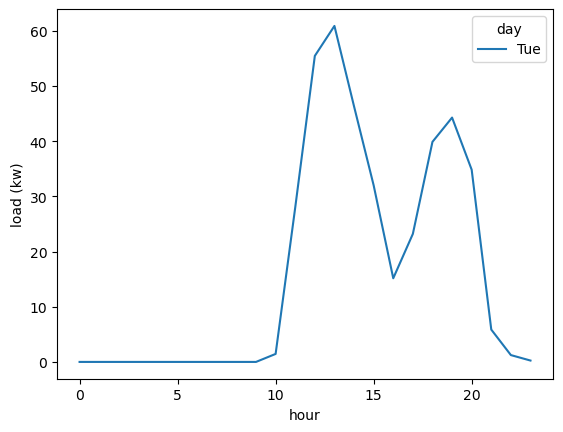

In [20]:
locid = 461655
particular_load_profile = total_load_profile[(total_load_profile['location_id']==locid) & \
                                                 (total_load_profile['day']=='Tue')
                                            ]

sns.lineplot(particular_load_profile,x='hour', y='load (kw)', hue='day')


In [22]:
total_load_profile.to_csv('load_profile_ev_charging_by_location_days.csv')

In [21]:
total_load_profile

,location_id,hour,load (kw),name,street_name,day,load (kw)_predict_mean,load (kw)_predict_std
0,461655,0,0.0,CEA-13654,6411 Mazarin,Tue,0.266288,-0.165833
1,461655,1,0.0,CEA-13654,6411 Mazarin,Tue,-0.674249,-1.084416
2,461655,2,0.0,CEA-13654,6411 Mazarin,Tue,0.022498,-0.939931
3,461655,3,0.0,CEA-13654,6411 Mazarin,Tue,0.430343,0.732783
4,461655,4,0.0,CEA-13654,6411 Mazarin,Tue,-0.732525,-0.360559
...,...,...,...,...,...,...,...,...
19,700367,19,0.0,CEA-14794,4990 Av. Clanranald,Sun,0.000000,0.000000
20,700367,20,0.0,CEA-14794,4990 Av. Clanranald,Sun,0.000000,0.000000
21,700367,21,0.0,CEA-14794,4990 Av. Clanranald,Sun,0.000000,0.000000
22,700367,22,0.0,CEA-14794,4990 Av. Clanranald,Sun,0.000000,0.000000


## OTPP finance GPT

In [5]:
import pandas as pd 
import seaborn as sns
import numpy as np 
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain.vectorstores import Chroma 
from langchain_community.embeddings import OpenAIEmbeddings
import os
with open('../assets/openai_api_key.txt', 'r') as f:
    key = f.read()
os.environ["OPENAI_API_KEY"]=key

finance_data = pd.read_csv('../data/otpp/financial_qa/Financial-QA-10k.csv')
finance_data['ticker'].unique()


problematic_questions = ['What does the Talent Management Equity Audit conducted by Chipotle involve?',
                         "What are the key elements of AbbVie's strategic objectives for 2024?",
                         
                        ]

In [ ]:

def create_chroma_vectorstore(texts, embedding_function=None, persist_directory='./chroma_db'):
    """
    Create a Chroma vector store using LangChain.
    
    Args:
        documents (list): List of strings or documents to vectorize
        embedding_function (Optional): Embedding function to use 
                                       (defaults to OpenAIEmbeddings if not provided)
        persist_directory (str): Directory to save the vector store
    
    Returns:
        Chroma: LangChain Chroma vector store
    """
    # Use OpenAI embeddings if no embedding function is provided
    if embedding_function is None:
        # Note: This requires OPENAI_API_KEY to be set in environment
        embedding_function = OpenAIEmbeddings()
        
    # Create and save the Chroma vector store
    vectorstore = Chroma.from_texts(
        texts=texts,
        embedding=embedding_function,
        persist_directory=persist_directory
    )
    
    return vectorstore


def load_chroma_vectorstore(persist_directory='./chroma_db', embedding_function=None):
    """
    Load an existing Chroma vector store.
    
    Args:
        persist_directory (str): Directory where the vector store is saved
        embedding_function (Optional): Embedding function to use 
                                       (defaults to OpenAIEmbeddings if not provided)
    
    Returns:
        Chroma: Loaded LangChain Chroma vector store
    """
    # Use OpenAI embeddings if no embedding function is provided
    if embedding_function is None:
        # Note: This requires OPENAI_API_KEY to be set in environment
        embedding_function = OpenAIEmbeddings()
    
    # Load the existing vector store
    vectorstore = Chroma(
        persist_directory=persist_directory,
        embedding_function=embedding_function
    )
    
    return vectorstore


In [7]:
#prepare the data 
texts = []
ticker_dict = {
    'NVDA': 'NVIDIA',
    'AAPL': 'Apple',
    'TSLA': 'Tesla',
    'LULU': 'Lululemon Athletica',
    'PG': 'Procter & Gamble',
    'COST': 'Costco Wholesale',
    'ABNB': 'Airbnb',
    'MSFT': 'Microsoft',
    'BRK-A': 'Berkshire Hathaway',
    'META': 'Meta Platforms',
    'AXP': 'American Express',
    'PTON': 'Peloton Interactive',
    'SBUX': 'Starbucks',
    'NKE': 'Nike',
    'PLTR': 'Palantir Technologies',
    'AMZN': 'Amazon',
    'NFLX': 'Netflix',
    'GOOGL': 'Alphabet (Google)',
    'ABBV': 'AbbVie',
    'V': 'Visa',
    'GME': 'GameStop',
    'AMC': 'AMC Entertainment',
    'CRM': 'Salesforce',
    'LLY': 'Eli Lilly',
    'AVGO': 'Broadcom',
    'UNH': 'UnitedHealth Group',
    'JNJ': 'Johnson & Johnson',
    'HD': 'Home Depot',
    'WMT': 'Walmart',
    'AMD': 'Advanced Micro Devices',
    'CVX': 'Chevron',
    'BAC': 'Bank of America',
    'KO': 'Coca-Cola',
    'T': 'AT&T',
    'AZO': 'AutoZone',
    'CAT': 'Caterpillar',
    'SCHW': 'Charles Schwab',
    'CMG': 'Chipotle Mexican Grill',
    'CB': 'Chubb',
    'CMCSA': 'Comcast',
    'CVS': 'CVS Health',
    'DVA': 'DaVita',
    'DAL': 'Delta Air Lines',
    'DLTR': 'Dollar Tree',
    'EBAY': 'eBay',
    'EA': 'Electronic Arts',
    'ENPH': 'Enphase Energy',
    'EFX': 'Equifax',
    'ETSY': 'Etsy',
    'FDX': 'FedEx',
    'F': 'Ford Motor Company',
    'GRMN': 'Garmin',
    'GIS': 'General Mills',
    'GM': 'General Motors',
    'GILD': 'Gilead Sciences',
    'GS': 'Goldman Sachs',
    'HAS': 'Hasbro',
    'HSY': 'Hershey',
    'HPE': 'Hewlett Packard Enterprise',
    'HLT': 'Hilton Worldwide',
    'HPQ': 'HP Inc.',
    'HUM': 'Humana',
    'IBM': 'International Business Machines',
    'ICE': 'Intercontinental Exchange',
    'INTU': 'Intuit',
    'IRM': 'Iron Mountain',
    'JPM': 'JPMorgan Chase',
    'KR': 'Kroger',
    'LVS': 'Las Vegas Sands'
}

#prepare the data 
texts = []
for _, row in finance_data.iterrows():
    texts.append(f"""Company Stock: {row['ticker']} 
Company Name: {ticker_dict[row['ticker']]} 
Filing year: {row['filing']}
Information: {row['context']}""")


vector_store = create_chroma_vectorstore(texts, 
                                         persist_directory='../vectorstores/finance_QA_openaiembedding')





C:\Users\konar\anaconda3\envs\urag\lib\site-packages\langchain_core\_api\deprecation.py:141: LangChainDeprecationWarning: The class `OpenAIEmbeddings` was deprecated in LangChain 0.0.9 and will be removed in 0.3.0. An updated version of the class exists in the langchain-openai package and should be used instead. To use it run `pip install -U langchain-openai` and import as `from langchain_openai import OpenAIEmbeddings`.
  warn_deprecated(


In [ ]:
additional_results = vector_store.similarity_search(
    query="CMG", 
    k=5
)


In [2]:
## finding hallucinating questions 
import warnings
warnings.filterwarnings('ignore')

import os 
from pathlib import Path
import re
from langchain.chains import LLMChain
from langchain.vectorstores import Chroma
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.prompts import PromptTemplate
import pandas as pd
import numpy as np 
from prompts.prompt_template import *
from utils.llm_apis import LocalOllama
from utils.hallucination_detection import CosineDetector, DeepEvalDetector
import spacy
from langchain_community.llms import Ollama

nlp = spacy.load("en_core_web_sm")

VECTOR_DB_PATHS = Path('../vectorstores/finance_QA_openaiembedding')
#load the vector dbs 
finance_db = Chroma(persist_directory=VECTOR_DB_PATHS.as_posix(), 
                                     embedding_function=OpenAIEmbeddings())

#load the llms and llm chains 

with open('../assets/openai_api_key.txt', 'r') as f:
    key = f.read()
os.environ["OPENAI_API_KEY"]=key
llm_ollama = Ollama(model='llama3.2', temperature=0.0, format='json', system="You are an LLM who is logical and is excellent at following instructions.")
llm_openai = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    max_retries=2,
    # api_key="...",
    # base_url="...",
    # organization="...",
    # other params...
)

#build the rephrase chain 
rephrase_prompt = PromptTemplate(input_variables=['input', 'chat_history'], template=RETRIEVE_REPHRASE_PROMPT_GA)
rephrase_chain = LLMChain(llm=llm_openai, prompt=rephrase_prompt)

#build the document chain
#st.session_state.rag_prompt = DOCUMENT_CHAIN_PROMPT
document_chain=LLMChain(llm=llm_openai,  prompt = DOCUMENT_CHAIN_PROMPT)

#load the hallucination detection method 
embedding_model = OpenAIEmbeddings(model="text-embedding-3-large")
hallucination_detector = DeepEvalDetector('faithfulness', 'gpt-4o-mini', async_mode=False)

#load the questions 
finance_questions_ans = pd.read_csv('../data/otpp/financial_qa/Financial-QA-10k.csv')
db_len = len(finance_questions_ans)

all_indexes = []
all_questions = []
all_responses = []
gt_responses = []
all_scores = []
qbank = []
max_qs = 20
search_k = 9
#query the system 
while len(qbank)<max_qs:
    rand_index = np.random.randint(0, db_len-1)
    query_text = finance_questions_ans.iloc[rand_index]['question']
    ground_truth_response = finance_questions_ans.iloc[rand_index]['answer']
    #run query 
    rel_docs_and_score = finance_db.similarity_search_with_score(query_text, 
                                                                    k=search_k,
                                                                    )
    docs = [tup[0] for tup in rel_docs_and_score]
    rag_response = document_chain.invoke({'input':query_text, 
                                        'context':docs})['text']
    regex = re.compile("[^a-zA-Z0-9.,!' $\n\-():]")
    result_clean = regex.sub('', rag_response)
    
    resp_sentences = [sent.text.strip() for sent in nlp(result_clean).sents] # spacy sentence tokenization
    if len(resp_sentences) <= 3:
        #resp_sent, scores = check_sentence_hallucination(resp_string, docs, result, sample_size=5)
        resp_sent, scores = hallucination_detector.check_hallucination('', result_clean, docs)
        if min(scores) < 0.5:
            qbank.append(query_text)

        all_indexes.append(rand_index)
        all_questions.append(query_text)
        all_responses.append(rag_response)
        all_scores.append(scores)
        gt_responses.append(ground_truth_response)

        print(f'\nIndex: {rand_index}\n Question: {query_text} \n\nResponse: {rag_response}, \n\nGT Response: {ground_truth_response} \n\nScores: {scores}\n\n\n')
        print('\n========================================\n')
    else:
        print("Skipping. \n Long response: ", result_clean)
        continue
print('\n\n\n#######################################\n')
print(qbank)





Index: 3672
 Question: What were the acquisition and integration-related costs for the year 2023? 

Response: The acquisition and integration-related costs for the year 2023 were $401 million for Charles Schwab. This amount includes $187 million of compensation and benefits, $135 million of professional services, $28 million of occupancy and equipment, and $27 million of other costs., 

GT Response: $401 million 

Scores: [1.0, 1.0]








Index: 5377
 Question: What was the allowance for loan losses on GM Financial’s retail finance receivables portfolio at the end of 2023? 

Response: The allowance for loan losses on GM Financial’s retail finance receivables portfolio was $2.3 billion as of December 31, 2023., 

GT Response: $2.3 billion 

Scores: [0.5]








Index: 4784
 Question: What approaches does the company use to analyze goodwill for potential impairment in the quantitative impairment test? 

Response: The company uses the market approach, when available and appropriate, or a combination of the income and market approaches to estimate the reporting unit’s fair value in the quantitative impairment test., 

GT Response: The company uses the market approach, or a combination of the income and market approaches, to analyze goodwill for potential impairment in the quantitative impairment test. 

Scores: [1.0]








Index: 688
 Question: What accounting treatment does the Company apply to refunds issued to customers? 

Response: The Company accounts for refunds issued to customers as variable consideration, which results in a reduction to revenue. The transaction price is reduced by the estimated amount of refunds., 

GT Response: The Company accounts for refunds as variable consideration, which results in a reduction to revenue. They reduce the transaction price by the estimated amount of the payments using the most likely outcome method based on known facts and circumstances and historical experience. 

Scores: [1.0, 0.0]








Index: 3931
 Question: How does the Internet Tax Freedom Act affect Comcast's business operations? 

Response: The Internet Tax Freedom Act plays a significant role in shaping the tax obligations and operational landscape for Comcast's internet-related services. This means that the Act influences how Comcast manages its tax responsibilities, which can impact its overall business operations and financial performance., 

GT Response: The Internet Tax Freedom Act prohibits most states and localities from imposing sales and other taxes on Comcast's internet access charges and from discriminating against electronic commerce. 

Scores: [0.5, 1.0]







...


Index: 2987
 Question: What were the Company's purchases from and resales to the ATMP JV during 2023 and 2022? 

Response: The provided context does not contain any information regarding the Company's purchases from and resales to the ATMP JV during 2023 and 2022. Therefore, I cannot provide an answer to that question based on the available information., 

GT Response: The Company's purchases from and resales to the ATMP JV during 2023 and 2022 both amounted to $1.7 billion and $14 million for purchases and resales respectively. In 2022, the purchases were also $1.7 billion while resales amounted to $15 million. 

Scores: [1.0, 1.0]








Index: 2388
 Question: What factors are considered in estimating a reserve for future product returns? 

Response: In estimating a reserve for future product returns, the company considers actual historical experience and any known events related to OEM and distributor arrangements., 

GT Response: Several factors are considered in estimating a reserve for future product returns, including historical return rates, expiration dates by product, estimated levels of inventory in wholesale and retail channels, and any specifically identified anticipated returns due to factors like the loss of patent exclusivity, product recalls, and changes in the competitive environment. 

Scores: [1.0]








Index: 2021
 Question: How significant is the fourth quarter to GameStop's annual sales and operating profit? 

Response: The provided context does not contain specific information regarding the significance of the fourth quarter to GameStop's annual sales and operating profit. Therefore, I cannot determine the importance of the fourth quarter based on the available information., 

GT Response: The fourth quarter is critically important, as GameStop generates the majority of its sales and operating profit during this period, which includes the holiday selling season. 

Scores: [1.0, 1.0]








Index: 3712
 Question: What key finding did the consultant report from the Talent Management Equity Audit at Chipotle? 

Response: The consultant concluded from the Talent Management Equity Audit that Chipotle has a robust set of processes, practices, and policies to enable equitable talent recruiting, development, and retention throughout the company. Additionally, the audit identified opportunities to strengthen Chipotle’s existing practices., 

GT Response: The consultant concluded that Chipotle has a robust set of processes, practices, and policies for equitable talent recruiting, development, and retention, and identified opportunities to strengthen existing practices. 

Scores: [0.0, 1.0]





Skipping. 
 Long response:  The key focus areas related to employee engagement at The Hershey Company include:

1. Continuous Listening: The company employs continuous listening surveys and quarterly town halls to gather employee feedback and strengthen engagement.
2. Training and Resource

KeyboardInterrupt: 

In [18]:
qbank

['How does Chipotle recognize revenue from White Label Sales?',
 'What initiatives does the company adopt to improve employee safety?',
 'Where can detailed information about commitments and contingencies be found in the 10-K report?',
 'How are foreign currency assets and liabilities managed in a U.S. dollar functional currency environment?',
 'What was the percentage increase in the revenue per package for FedEx Ground in 2022?',
 'How does the company calculate the Average Net Monthly Connected Fitness Churn?',
 'What is included in the index to Management’s Discussion and Analysis of Financial Condition and Results of Operations?',
 'What are the new requirements proposed by the EPA for the power sector to address GHG emissions, effective January 1, 2030?',
 'What role does Google envision for AI in society?',
 "What does eBay's Authenticity Guarantee service offer?",
 'What is included in Item 8 of the document?',
 'What steps has the company taken to manage cybersecurity risks?',

In [15]:
qbank2

["How much did the company's revenues decrease in 2023 compared to 2022?",
 "What steps will be taken to monitor the Asia Pacific reporting unit's performance against possible impairment?",
 'How does the company ensure compliance with U.S. and international laws?',
 "How does the company's manufacturing and materials usage influence its operational strategy?",
 'What is the therapeutic purpose of Letairis?',
 'What was the operating income for 2023, and how did it compare to 2022?']

In [23]:
full_qbank = qbank.extend(qbank2)


TypeError: 'NoneType' object is not iterable

In [28]:
with open('./questions.txt', 'w') as f:
    for q in qbank:
        f.write(f'{q}\n')

In [27]:
full_qbank